In [ ]:
# Resolve to the repo root so data/, figures/, and paper_figures/ paths work
# regardless of where the kernel started (this notebook lives in notebooks/).
import os
while not os.path.isdir("llm_polysemy") and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")


# LLM Polysemy Benchmark — Combined Results

**How do image-generation and text models resolve ambiguous words?**

Each experiment sends a single polysemous word (e.g. *bank*, *trunk*, *bolt*) as a bare prompt — no context, no hint — to every model. An LLM judge then classifies the model's output into one of the word's listed senses. Repeating this 30 times per word reveals each model's *sense distribution*: which meaning it defaults to, and how confidently.

> **What this is getting at:** does each modality default to a *different* sense — image models to the most **depictable** meaning, text models to the most **frequent** meaning — and what happens on words where those two disagree (e.g. *mine* → a pit/bomb in images vs. “belonging to me” in text)?

This notebook combines results from **two modalities**:
- **Image**: a text-to-image model renders the word → the judge classifies the depicted sense
- **Text**: an LLM writes one sentence using the word → the judge classifies the sense used

Both modalities use the same two judges (GPT and Gemini) so their distributions are directly comparable.

---

**Notebook sections**
1. Data loading & dataset overview
2. Per-word sense distributions (interactive)
3. Model similarity matrices
4. Family cohesion analysis
5. Alignment with text-frequency priors
6. Per-word inter-model disagreement
7. Cross-modality comparison (image vs text)
8. Model geometry (PCA)


## Setup

Run this cell first — it sets the working directory, imports libraries, and defines the shared helper functions used throughout the notebook.

In [3]:
import os, json, sys, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Patch
from itertools import combinations
from pathlib import Path
from scipy.spatial.distance import jensenshannon
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.stats import pearsonr
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from IPython.display import display, HTML
import pandas as pd

# ipywidgets powers the interactive cells (sections 2 / 2b). It's optional — if
# it isn't installed in this kernel, those cells fall back to a static render.
try:
    import ipywidgets as widgets
    HAS_WIDGETS = True
except ModuleNotFoundError:
    widgets = None
    HAS_WIDGETS = False
    print('ipywidgets not found — interactive cells will render a static default '
          '(pip install ipywidgets to enable the dropdowns).')

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110

# ── Working directory: find the project root wherever the notebook is run ──────
# Walk up from the current dir looking for the repo markers (the package + the
# data dir) instead of hard-coding an absolute path, so this runs on any machine.
def _find_project_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / 'llm_polysemy').is_dir() and (base / 'data' / 'meanings.json').is_file():
            return base
    raise FileNotFoundError(
        'Could not locate the llm-polysemy project root (a directory containing '
        'the `llm_polysemy/` package and `data/meanings.json`). Launch this '
        'notebook from inside the repo.')

PROJECT_ROOT = _find_project_root()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')

from llm_polysemy import registry
from llm_polysemy.registry import (
    FAMILY_ORDER, FAMILY_DISPLAY, FAMILY_COLOR,
    SENSE_PALETTE, EXTRA_LABELS, EXTRA_COLORS,
)


# ── Core analysis helpers ──────────────────────────────────────────
def get_senses(word):
    return [s['sense'] for s in meanings.get(word, [])]

def get_vocab(word, word_data, judge='gpt'):
    seen = set()
    judges = ('gpt', 'gemini') if judge == 'consensus' else (judge,)
    for m_data in word_data.values():
        for j in judges:
            node = m_data.get(j)
            if node:
                seen.update(node.get('_counts', {}).keys())
    vocab = get_senses(word)[:]
    for lbl in EXTRA_LABELS + sorted(seen):
        if lbl not in vocab:
            vocab.append(lbl)
    return vocab

def model_dist(counts, vocab):
    vec = np.array([counts.get(s, 0) for s in vocab], dtype=float)
    total = vec.sum()
    return vec / total if total > 0 else None

def dist_for(m_data, vocab, judge='gpt'):
    if judge == 'consensus':
        ds = []
        for j in ('gpt', 'gemini'):
            node = m_data.get(j)
            if node:
                d = model_dist(node.get('_counts', {}), vocab)
                if d is not None:
                    ds.append(d)
        if not ds: return None
        m = np.mean(ds, axis=0); s = m.sum()
        return m / s if s > 0 else None
    node = m_data.get(judge)
    if not node: return None
    return model_dist(node.get('_counts', {}), vocab)

def text_dist(word, vocab, freq):
    tf = freq.get(word, {})
    vec = np.array([tf.get(s, 0.0) for s in vocab], dtype=float)
    s = vec.sum()
    return vec / s if s > 0 else None

def js(p, q):
    """Jensen-Shannon *distance* (base-2): the square root of the JS distance.

    scipy.spatial.distance.jensenshannon returns the distance, not the divergence.
    The distance is a true metric bounded in [0, 1] — 0 when p == q, 1 when the
    two distributions share no support. That [0, 1] bound is exactly why `1 - js`
    is a valid similarity and why the matrix can be fed to hierarchical clustering
    (a metric, unlike a raw divergence). Labelled "JS distance" throughout."""
    return float(jensenshannon(p, q, base=2))

def entropy(p, base=2):
    """Shannon entropy of a probability vector, in bits (base-2).

    Measures how spread-out a model's sense choices are: 0 when it always picks a
    single sense, log2(k) when it splits its 30 samples evenly across k senses.
    Higher entropy = the model is more 'diverse' / less decisive for that word."""
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return float(-np.sum(p * np.log(p) / np.log(base)))

def mean_pairwise_js(dists):
    pairs = list(combinations(dists, 2))
    if not pairs: return np.nan
    return float(np.mean([js(a, b) for a, b in pairs]))

def sense_colors(senses):
    colors = {s: SENSE_PALETTE[i % len(SENSE_PALETTE)] for i, s in enumerate(senses)}
    colors.update(EXTRA_COLORS)
    return colors

def family_of(key):  return registry.MODELS[key].family
def dlabel(key):     return registry.MODELS[key].label
def fcolor(fam):     return FAMILY_COLOR[fam]
def flabel(fam):     return FAMILY_DISPLAY[fam]

print('Setup complete.')

Project root: /Users/addisonwu/Desktop/llm-polysemy
Setup complete.


## 1. Dataset Overview

We load four JSON files produced by the benchmark pipeline:
- `data/histograms_image.json` — aggregated sense distributions for the image modality
- `data/histograms_text.json` — same for the text modality
- `data/meanings.json` — canonical sense definitions for each word
- `data/freq_manual.json` / `freq_wiki.json` — human-estimated and Wikipedia-derived text-frequency priors (used as a baseline for how often each sense appears in ordinary English)

Both pipelines are complete:

- **Image** (`histograms_image.json`): 100 words × 17 models, fully classified and aggregated.
- **Text** (`histograms_text.json`): 100 words × 15 models, fully classified and aggregated.

All 100 words are available in both modalities, enabling a full cross-modality comparison.


In [4]:
# ── Load all data ─────────────────────────────────────────────
hist_image  = json.loads(Path('data/histograms_image.json').read_text())
hist_text   = json.loads(Path('data/histograms_text.json').read_text())
meanings    = json.loads(Path('data/meanings.json').read_text())
freq_manual = json.loads(Path('data/freq_manual.json').read_text())
freq_wiki   = json.loads(Path('data/freq_wiki.json').read_text())

IMAGE_MODELS = registry.models_for('image')
TEXT_MODELS  = registry.models_for('text')
IMAGE_WORDS  = sorted(hist_image.keys())
TEXT_WORDS   = sorted(hist_text.keys())
BOTH_WORDS   = sorted(set(IMAGE_WORDS) & set(TEXT_WORDS))

print(f'Image histogram:  {len(IMAGE_WORDS)} words  ×  {len(IMAGE_MODELS)} models')
print(f'Text histogram:   {len(TEXT_WORDS)} words  ×  {len(TEXT_MODELS)} models')
print(f'Words in both:    {len(BOTH_WORDS)}')
print(f'\nWords with both modalities: {BOTH_WORDS}')

Image histogram:  100 words  ×  17 models
Text histogram:   100 words  ×  17 models
Words in both:    100

Words with both modalities: ['amazon', 'anchor', 'apple', 'ash', 'ball', 'band', 'bank', 'bar', 'bark', 'barrel', 'basket', 'bass', 'bat', 'batter', 'beam', 'bench', 'block', 'bolt', 'bow', 'bowl', 'box', 'bridge', 'brush', 'buck', 'bug', 'button', 'cane', 'cape', 'capital', 'cardinal', 'case', 'cast', 'cell', 'charge', 'chest', 'chip', 'club', 'coach', 'cobbler', 'cobra', 'crane', 'crown', 'drill', 'fan', 'file', 'fire', 'fly', 'fox', 'grave', 'hide', 'iron', 'jack', 'jaguar', 'jordan', 'key', 'lodge', 'mars', 'match', 'mercury', 'mine', 'mole', 'mortar', 'mustang', 'nail', 'paddle', 'pen', 'pitch', 'pitcher', 'plane', 'pool', 'port', 'post', 'press', 'pump', 'python', 'ram', 'ring', 'rock', 'scale', 'seal', 'shot', 'shuttle', 'socket', 'spring', 'staple', 'stock', 'strike', 'switch', 'tank', 'tap', 'tie', 'tip', 'toast', 'track', 'train', 'trunk', 'turkey', 'watch', 'wave', 'wil

In [5]:
# ── Coverage tables ───────────────────────────────────────────
def coverage_table(hist, models, label):
    rows = []
    for m in models:
        n = sum(1 for w in hist if m in hist[w])
        rows.append({'Model': dlabel(m), 'Family': flabel(family_of(m)), 'Words covered': n})
    df = pd.DataFrame(rows)
    print(f'\n{label} model coverage:')
    display(df.style.bar(subset=['Words covered'], color='#4C72B0', vmin=0))

coverage_table(hist_image, IMAGE_MODELS, 'Image')
coverage_table(hist_text,  TEXT_MODELS,  'Text')


Image model coverage:


,Model,Family,Words covered
0,gpt-image-1,OpenAI,100
1,gpt-image-1-mini,OpenAI,100
2,gpt-image-1.5,OpenAI,100
3,gpt-image-2,OpenAI,100
4,grok-base,Grok,100
5,grok-pro,Grok,100
6,grok-quality,Grok,100
7,gemini-2.5-flash,Gemini,100
8,gemini-3.1-flash,Gemini,100
9,gemini-3-pro,Gemini,100



Text model coverage:


,Model,Family,Words covered
0,gpt-3.5-turbo,OpenAI,100
1,gpt-4o,OpenAI,100
2,gpt-5,OpenAI,100
3,gpt-5.4-nano,OpenAI,100
4,gpt-5.4-mini,OpenAI,100
5,gpt-5.5,OpenAI,100
6,grok-4.20,Grok,100
7,grok-4.20-nr,Grok,100
8,grok-4.3,Grok,100
9,gemini-2.5-flash,Gemini,100


In [6]:
# ── Sense inventory summary ───────────────────────────────────
rows = []
for word in IMAGE_WORDS:
    senses = get_senses(word)
    rows.append({'Word': word, 'N senses': len(senses), 'Senses': ', '.join(senses)})
df_words = pd.DataFrame(rows).set_index('Word')
print('Sense inventory (image words):')
display(df_words)

Sense inventory (image words):


,N senses,Senses
Word,,
amazon,4,"river, rainforest, company, warrior"
anchor,3,"ship, news, secure"
apple,2,"fruit, company"
ash,2,"residue, tree"
ball,3,"sphere, dance, fun"
...,...,...
trunk,5,"tree, car, elephant, body, luggage"
turkey,5,"bird, country, food, bowling, failure"
watch,3,"timepiece, observe, guard"


## 2. Per-Word Sense Distributions (Interactive)

Each bar in the chart below shows the proportion of the 30 samples where a given model chose each sense. Use the widgets to switch between words, modalities, and judges.

- **Stacked bars** represent the mix of senses a model chose across all 30 samples.
- **`multiple`** means the judge found evidence of more than one sense in a single output.
- **`unclear`** means the judge could not determine a sense from the output.

> **Tip:** try `bank` (finance vs river) or `trunk` (elephant vs tree vs car) to see dramatic differences between model families.

In [7]:
def plot_word_hist(word, modality, judge):
    hist = hist_image if modality == 'image' else hist_text
    models = IMAGE_MODELS if modality == 'image' else TEXT_MODELS
    if word not in hist:
        print(f'No {modality} data for "{word}"'); return
    word_data = hist[word]
    senses = get_senses(word)
    vocab = get_vocab(word, word_data, judge)
    all_labels = senses + [l for l in ['multiple', 'unclear', 'other'] if l in vocab]
    color_map = sense_colors(senses)
    present = [m for m in models if m in word_data]
    if not present:
        print(f'No classified models for "{word}" ({modality})'); return

    x = np.arange(len(present))
    fig, ax = plt.subplots(figsize=(max(10, len(present) * 0.8), 4.5))
    bottoms = np.zeros(len(present))
    for lbl in all_labels:
        idx = vocab.index(lbl) if lbl in vocab else -1
        vals = []
        for m in present:
            d = dist_for(word_data[m], vocab, judge)
            vals.append(float(d[idx]) if d is not None and idx >= 0 else 0.0)
        vals = np.array(vals)
        if vals.sum() == 0: continue
        ax.bar(x, vals, 0.65, bottom=bottoms,
               color=color_map.get(lbl, '#999999'), label=lbl, zorder=3)
        for xi, (v, b) in enumerate(zip(vals, bottoms)):
            if v > 0.06:
                ax.text(xi, b + v / 2, f'{v:.0%}', ha='center', va='center',
                        fontsize=7, color='white', fontweight='bold')
        bottoms += vals

    ax.set_xticks(x)
    ax.set_xticklabels([dlabel(m) for m in present], rotation=40, ha='right', fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Proportion of samples', fontsize=10)
    ax.set_title(f'"{word}" — sense distributions ({modality} models, {judge} judge)', fontsize=12)
    ax.legend(loc='upper right', fontsize=9, framealpha=0.8)
    ax.grid(axis='y', alpha=0.3, zorder=0)
    plt.tight_layout(); plt.show()

    print(f'Sense definitions for "{word}":')
    for s in meanings.get(word, []):
        print(f'  {s["sense"]:12s} — {s["meaning"]}')


# ── Widgets (fall back to a static render when ipywidgets is absent) ──
if HAS_WIDGETS:
    _out = widgets.Output()
    _mod_w = widgets.ToggleButtons(options=['image', 'text'], description='Modality:',
                                    style={'description_width': '80px'})
    _word_w = widgets.Dropdown(options=IMAGE_WORDS, description='Word:',
                                style={'description_width': '80px'})
    _judge_w = widgets.RadioButtons(options=['gpt', 'gemini', 'consensus'],
                                     description='Judge:', style={'description_width': '80px'})

    def _update_words(change):
        _word_w.options = IMAGE_WORDS if _mod_w.value == 'image' else TEXT_WORDS

    def _redraw(*_):
        _out.clear_output(wait=True)
        with _out:
            plot_word_hist(_word_w.value, _mod_w.value, _judge_w.value)

    _mod_w.observe(_update_words, names='value')
    for w in (_mod_w, _word_w, _judge_w):
        w.observe(_redraw, names='value')

    display(widgets.VBox([
        widgets.HBox([_mod_w, _judge_w]),
        _word_w,
        _out,
    ]))
    _redraw()
else:
    # Static fallback: render a couple of illustrative words.
    for _w in ('bank', 'trunk'):
        plot_word_hist(_w, 'image', 'gpt')

### 2b. Model Distributions vs Text-Frequency Prior

To understand whether a model's sense preference reflects word usage in natural language, we compare it against a **text-frequency prior**: the estimated probability of each sense in everyday written English. Two priors are available:
- **manual** — researcher-estimated from dictionary frequencies and common usage
- **wiki** — derived from Wikipedia article proportions for each sense

The leftmost bar `[text freq]` is the prior. A model that closely matches the prior uses the word the way an average English sentence would. A model that diverges has its own systematic bias toward certain senses.

In [8]:
def plot_word_vs_freq(word, modality, judge, prior_name):
    hist = hist_image if modality == 'image' else hist_text
    models = IMAGE_MODELS if modality == 'image' else TEXT_MODELS
    freq = freq_manual if prior_name == 'manual' else freq_wiki
    if word not in hist:
        print(f'No {modality} data for "{word}"'); return
    word_data = hist[word]
    senses = get_senses(word)
    vocab = get_vocab(word, word_data, judge)
    all_labels = senses + [l for l in ['multiple', 'unclear', 'other'] if l in vocab]
    color_map = sense_colors(senses)
    present = [m for m in models if m in word_data]
    if not present:
        print(f'No classified models for "{word}" ({modality})'); return
    tf_vec = text_dist(word, vocab, freq)

    cols = ['[text freq]'] + present
    x = np.arange(len(cols))
    fig, ax = plt.subplots(figsize=(max(10, len(cols) * 0.8), 4.5))
    bottoms = np.zeros(len(cols))
    for lbl in all_labels:
        idx = vocab.index(lbl) if lbl in vocab else -1
        vals = []
        for col in cols:
            if col == '[text freq]':
                vals.append(float(tf_vec[idx]) if tf_vec is not None and idx >= 0 else 0.0)
            else:
                d = dist_for(word_data[col], vocab, judge)
                vals.append(float(d[idx]) if d is not None and idx >= 0 else 0.0)
        vals = np.array(vals)
        if vals.sum() == 0: continue
        ax.bar(x, vals, 0.65, bottom=bottoms,
               color=color_map.get(lbl, '#999999'), label=lbl, zorder=3)
        bottoms += vals

    ax.axvline(0.5, color='gray', linewidth=1.2, linestyle='--', alpha=0.7)
    tick_labels = ['text\nfreq'] + [dlabel(m) for m in present]
    ax.set_xticks(x)
    ax.set_xticklabels(tick_labels, rotation=40, ha='right', fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Proportion', fontsize=10)
    ax.set_title(f'"{word}" — models vs {prior_name} text-frequency prior ({judge} judge)', fontsize=11)
    ax.legend(loc='upper right', fontsize=9, framealpha=0.8)
    ax.grid(axis='y', alpha=0.3, zorder=0)
    plt.tight_layout(); plt.show()

    if tf_vec is not None:
        print('JS distance from prior:')
        js_vals = []
        for m in present:
            d = dist_for(word_data[m], vocab, judge)
            if d is not None:
                v = js(tf_vec, d)
                js_vals.append((dlabel(m), v))
        for lbl, v in sorted(js_vals, key=lambda x: x[1]):
            bar = '█' * int(v / 0.02)
            print(f'  {lbl:22s}  {v:.4f}  {bar}')


# ── Widgets (fall back to a static render when ipywidgets is absent) ──
if HAS_WIDGETS:
    _out2 = widgets.Output()
    _mod2_w = widgets.ToggleButtons(options=['image', 'text'], description='Modality:',
                                     style={'description_width': '80px'})
    _word2_w = widgets.Dropdown(options=IMAGE_WORDS, description='Word:',
                                 style={'description_width': '80px'})
    _judge2_w = widgets.RadioButtons(options=['gpt', 'gemini', 'consensus'],
                                      description='Judge:', style={'description_width': '80px'})
    _prior_w = widgets.RadioButtons(options=['manual', 'wiki'],
                                     description='Prior:', style={'description_width': '80px'})

    def _update2_words(change):
        _word2_w.options = IMAGE_WORDS if _mod2_w.value == 'image' else TEXT_WORDS

    def _redraw2(*_):
        _out2.clear_output(wait=True)
        with _out2:
            plot_word_vs_freq(_word2_w.value, _mod2_w.value, _judge2_w.value, _prior_w.value)

    _mod2_w.observe(_update2_words, names='value')
    for w in (_mod2_w, _word2_w, _judge2_w, _prior_w):
        w.observe(_redraw2, names='value')

    display(widgets.VBox([
        widgets.HBox([_mod2_w, _judge2_w, _prior_w]),
        _word2_w,
        _out2,
    ]))
    _redraw2()
else:
    # Static fallback: render a couple of illustrative words.
    for _w in ('bank', 'trunk'):
        plot_word_vs_freq(_w, 'image', 'gpt', 'manual')

## 3. Model Similarity Matrix

For every pair of models, we compute the **mean Jensen–Shannon (JS) distance** between their sense distributions, averaged over all words where both have data. JS distance is 0 when two distributions are identical and 1 when they share no mass.

We then convert to **similarity = 1 − JS** and cluster the matrix hierarchically (average linkage) so models with similar behaviour are placed adjacent.

**What to look for:**
- A bright-green diagonal cluster = models that agree on which sense to pick.
- Cross-family similarity = two providers whose models implicitly learned the same biases.

=== IMAGE models ===


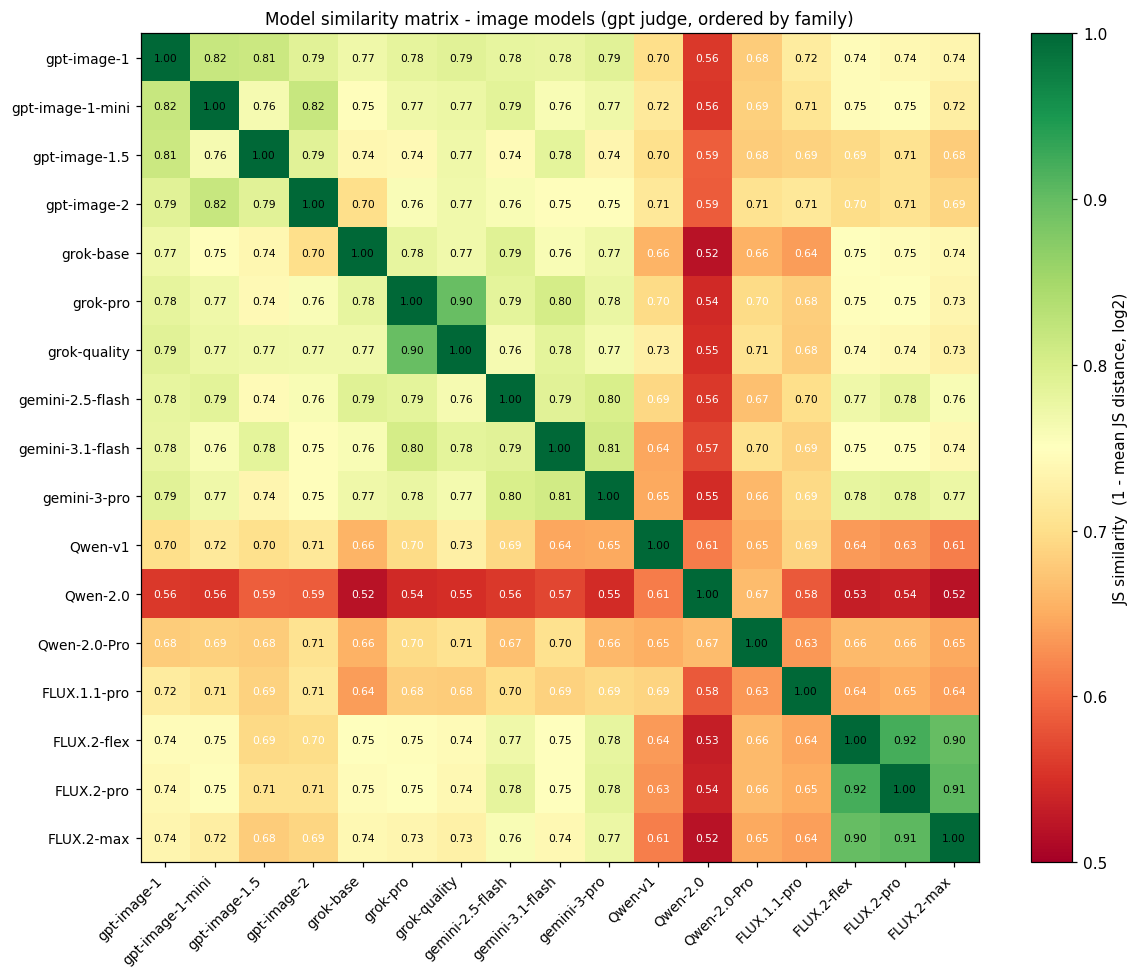

In [9]:
# Shared color scale for BOTH similarity heatmaps (image + text), so identical
# JS-similarity values map to identical colors across the two plots.
SIM_VMIN, SIM_VMAX = 0.5, 1.0

def plot_similarity(modality, judge='gpt', title_suffix='', vmin=SIM_VMIN, vmax=SIM_VMAX):
    hist = hist_image if modality == 'image' else hist_text
    models = IMAGE_MODELS if modality == 'image' else TEXT_MODELS
    n = len(models)

    sum_js = np.zeros((n, n))
    cnt    = np.zeros((n, n))
    for word, word_data in hist.items():
        vocab = get_vocab(word, word_data, judge)
        dists = {i: d for i, m in enumerate(models)
                 if m in word_data
                 and (d := dist_for(word_data[m], vocab, judge)) is not None}
        for i in dists:
            for j in dists:
                if i >= j: continue
                v = js(dists[i], dists[j])
                sum_js[i,j] += v; sum_js[j,i] += v
                cnt[i,j] += 1;   cnt[j,i] += 1

    with np.errstate(invalid='ignore'):
        avg_js = np.where(cnt > 0, sum_js / cnt, np.nan)
    np.fill_diagonal(avg_js, 0.0)
    sim = 1 - avg_js

    # Order models the SAME way in both modalities: by provider family (registry
    # order) then generation index, instead of per-matrix hierarchical clustering.
    # This makes the image and text heatmaps directly comparable (shared families
    # appear in the same sequence).
    fam_rank = {f: i for i, f in enumerate(FAMILY_ORDER)}
    order = sorted(range(n), key=lambda i: (
        fam_rank.get(family_of(models[i]), len(FAMILY_ORDER)),
        registry.MODELS[models[i]].generation_index if models[i] in registry.MODELS else 0,
        dlabel(models[i])))
    sim_ord = sim[np.ix_(order, order)]
    tick_labels = [dlabel(models[i]) for i in order]

    fig, ax = plt.subplots(figsize=(11, 9))
    im = ax.imshow(sim_ord, vmin=vmin, vmax=vmax, cmap='RdYlGn', aspect='auto')
    plt.colorbar(im, ax=ax, label='JS similarity  (1 - mean JS distance, log2)')
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(tick_labels, fontsize=9)
    for i in range(n):
        for j in range(n):
            v = sim_ord[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=7, color='black' if v > 0.7 else 'white')
    ax.set_title(f'Model similarity matrix - {modality} models ({judge} judge, ordered by family){title_suffix}',
                 fontsize=11)
    plt.tight_layout(); plt.show()
    return avg_js, models

print('=== IMAGE models ===')
avg_js_img, img_models = plot_similarity('image')


=== TEXT models ===


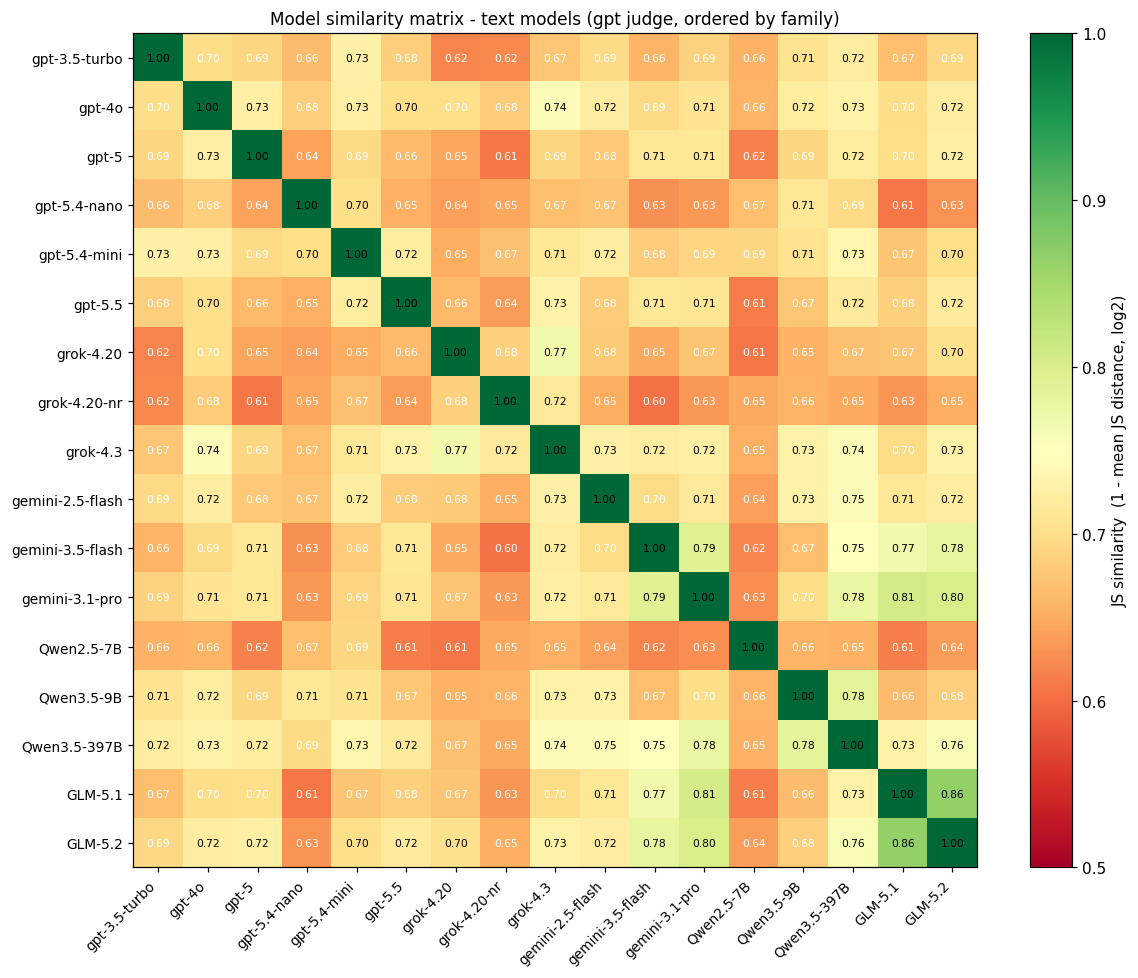

In [10]:
print('=== TEXT models ===')
avg_js_txt, txt_models = plot_similarity('text')

## 4. Family Cohesion

Do models from the same provider cluster together? We measure **within-family JS** (mean pairwise distance among siblings) vs **between-family JS** (mean distance to all other families' models). A high ratio means models within a family are more similar to each other than to outsiders — i.e., the provider has a consistent 'house style' for resolving ambiguity.

=== IMAGE family cohesion ===


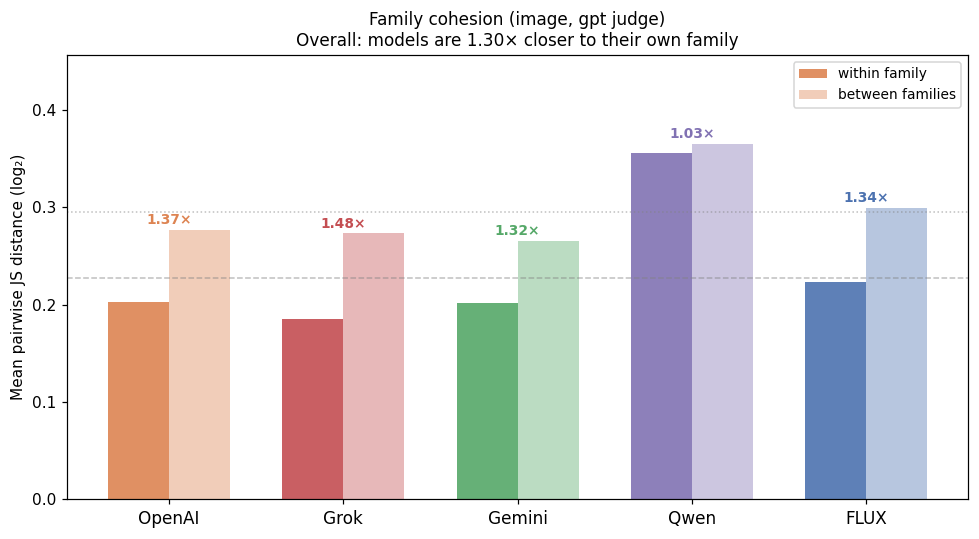

,Family,Within-family JS,Between-family JS,Ratio
0,OpenAI,0.2023,0.2770,1.37×
1,Grok,0.1850,0.2731,1.48×
2,Gemini,0.2012,0.2658,1.32×
3,Qwen,0.3561,0.3652,1.03×
4,FLUX,0.2229,0.2993,1.34×


In [11]:
def plot_family_cohesion(modality, judge='gpt'):
    hist = hist_image if modality == 'image' else hist_text
    models = IMAGE_MODELS if modality == 'image' else TEXT_MODELS
    n = len(models)

    # Build avg_js matrix
    sum_js = np.zeros((n, n)); cnt = np.zeros((n, n))
    for word, word_data in hist.items():
        vocab = get_vocab(word, word_data, judge)
        dists = {i: d for i, m in enumerate(models)
                 if m in word_data and (d := dist_for(word_data[m], vocab, judge)) is not None}
        for i in dists:
            for j in dists:
                if i >= j: continue
                v = js(dists[i], dists[j])
                sum_js[i,j] += v; sum_js[j,i] += v
                cnt[i,j] += 1;   cnt[j,i] += 1
    with np.errstate(invalid='ignore'):
        avg_js = np.where(cnt > 0, sum_js / cnt, np.nan)
    np.fill_diagonal(avg_js, 0.0)

    fams = registry.families(modality)
    rows, within_all, between_all = [], [], []
    for fam in fams:
        fi   = [i for i, m in enumerate(models) if family_of(m) == fam]
        oi   = [i for i, m in enumerate(models) if family_of(m) != fam]
        wi   = [avg_js[i,j] for i,j in combinations(fi, 2) if not np.isnan(avg_js[i,j])]
        bi   = [avg_js[i,j] for i in fi for j in oi if not np.isnan(avg_js[i,j])]
        w = np.mean(wi) if wi else np.nan
        b = np.mean(bi) if bi else np.nan
        rows.append((fam, w, b, b/w if w and w > 0 else np.nan))
        within_all.extend(wi); between_all.extend(bi)

    w_all = np.mean(within_all); b_all = np.mean(between_all)
    ratio_all = b_all / w_all

    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(fams))
    colors = [fcolor(f) for f in fams]
    ax.bar(x - 0.175, [r[1] for r in rows], 0.35, color=colors, alpha=0.9, label='within family')
    ax.bar(x + 0.175, [r[2] for r in rows], 0.35, color=colors, alpha=0.4, label='between families')
    ax.axhline(w_all, color='gray', lw=1, ls='--', alpha=0.5)
    ax.axhline(b_all, color='gray', lw=1, ls=':', alpha=0.5)
    for i, (fam, w, b, r) in enumerate(rows):
        if not np.isnan(r):
            ax.text(i, max(w, b) + 0.006, f'{r:.2f}×', ha='center',
                    fontsize=9, fontweight='bold', color=fcolor(fam))
    ax.set_xticks(x); ax.set_xticklabels([flabel(f) for f in fams], fontsize=11)
    ax.set_ylabel('Mean pairwise JS distance (log₂)')
    ax.set_title(f'Family cohesion ({modality}, {judge} judge)\n'
                 f'Overall: models are {ratio_all:.2f}× closer to their own family', fontsize=11)
    ax.legend(fontsize=9)
    valid_b = [r[2] for r in rows if not np.isnan(r[2])]
    if valid_b: ax.set_ylim(0, max(valid_b) * 1.25)
    plt.tight_layout(); plt.show()

    df = pd.DataFrame([{'Family': flabel(f), 'Within-family JS': f'{w:.4f}',
                         'Between-family JS': f'{b:.4f}', 'Ratio': f'{r:.2f}×'}
                        for f, w, b, r in rows])
    display(df)

print('=== IMAGE family cohesion ===')
plot_family_cohesion('image')

=== TEXT family cohesion ===


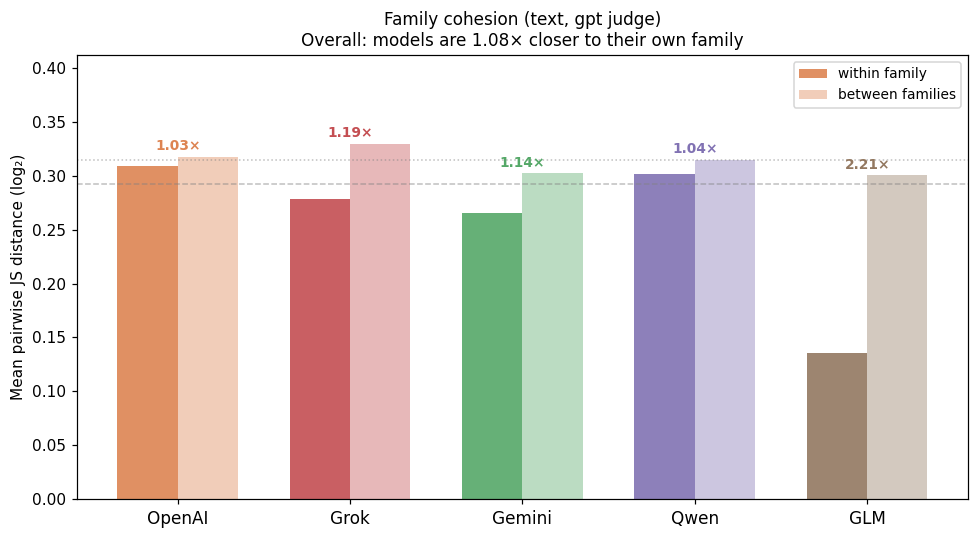

,Family,Within-family JS,Between-family JS,Ratio
0,OpenAI,0.3086,0.3177,1.03×
1,Grok,0.2780,0.3295,1.19×
2,Gemini,0.2657,0.3025,1.14×
3,Qwen,0.3014,0.3148,1.04×
4,GLM,0.1359,0.3007,2.21×


In [12]:
print('=== TEXT family cohesion ===')
plot_family_cohesion('text')

## 5. Alignment with Text-Frequency Priors

We measure how much each model's sense distribution diverges from the text-frequency prior using **JS(prior ‖ model)**. A low score means the model picks senses roughly as often as they occur in ordinary English. A high score means it has developed its own bias — e.g. always drawing `bank` as a financial institution even though the river sense is more common in natural text.

### 5a. Per-model mean JS from prior (ranked bar chart)


=== IMAGE: text-frequency divergence ===


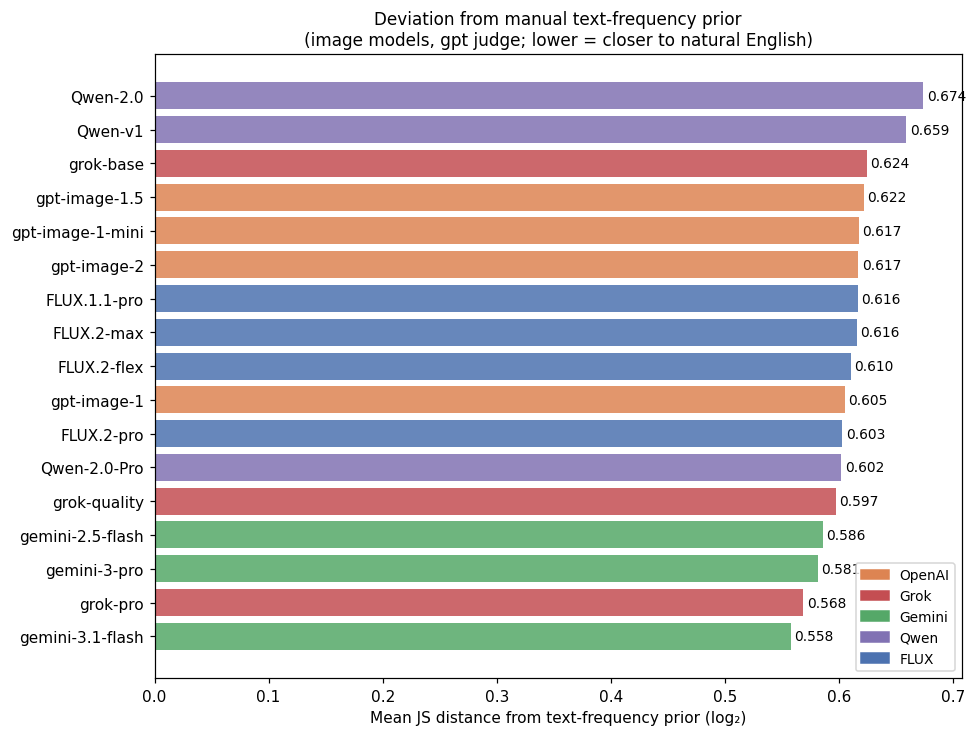

In [13]:
def plot_text_divergence(modality, judge='gpt', prior_name='manual'):
    hist = hist_image if modality == 'image' else hist_text
    models = IMAGE_MODELS if modality == 'image' else TEXT_MODELS
    freq = freq_manual if prior_name == 'manual' else freq_wiki

    model_js = {}
    for word, word_data in hist.items():
        vocab = get_vocab(word, word_data, judge)
        tf = text_dist(word, vocab, freq)
        if tf is None: continue
        for m in models:
            if m not in word_data: continue
            d = dist_for(word_data[m], vocab, judge)
            if d is None: continue
            v = js(tf, d)
            if not np.isnan(v):
                model_js.setdefault(m, []).append(v)

    ranked = sorted(((m, float(np.mean(v))) for m, v in model_js.items()), key=lambda x: x[1])
    labels  = [dlabel(m) for m, _ in ranked]
    values  = [v for _, v in ranked]
    colors  = [fcolor(family_of(m)) for m, _ in ranked]

    fig, ax = plt.subplots(figsize=(9, max(5, len(ranked) * 0.4)))
    y = np.arange(len(ranked))
    ax.barh(y, values, color=colors, alpha=0.85)
    ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel('Mean JS distance from text-frequency prior (log₂)')
    ax.set_title(f'Deviation from {prior_name} text-frequency prior\n'
                 f'({modality} models, {judge} judge; lower = closer to natural English)', fontsize=11)
    for i, (m, v) in enumerate(ranked):
        ax.text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=9)
    fams = registry.families(modality)
    ax.legend(handles=[Patch(color=fcolor(f), label=flabel(f)) for f in fams],
              loc='lower right', fontsize=9)
    plt.tight_layout(); plt.show()

print('=== IMAGE: text-frequency divergence ===')
plot_text_divergence('image')

=== TEXT: text-frequency divergence ===


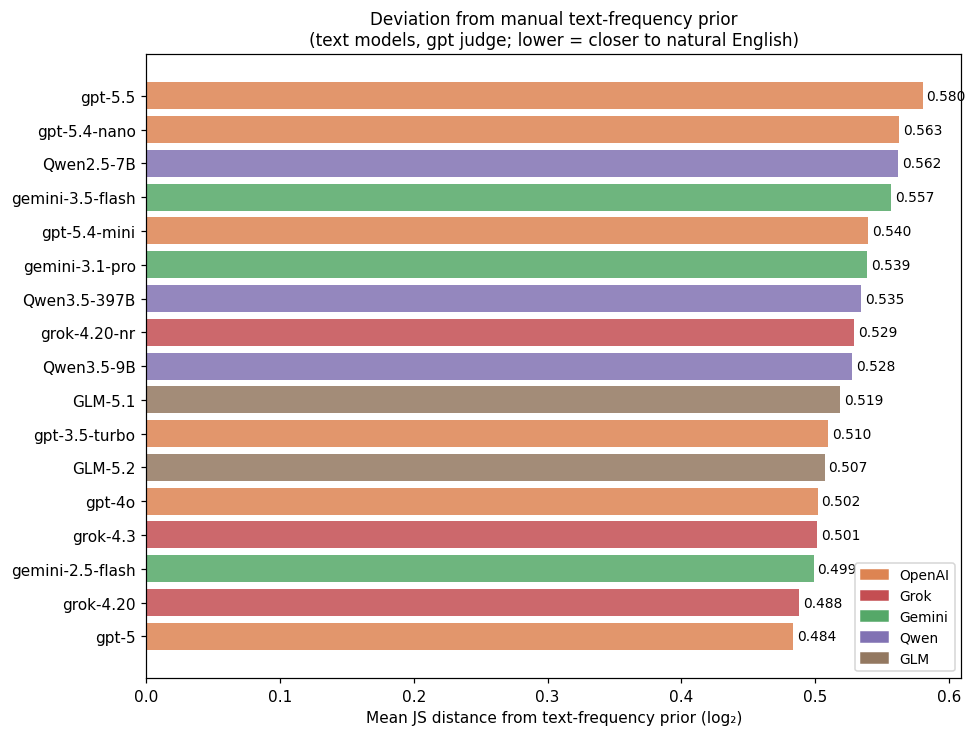

In [14]:
print('=== TEXT: text-frequency divergence ===')
plot_text_divergence('text')

### 5b. Generation Trend — Does newer = closer to natural English?

We plot each family's models on the x-axis by generation index (oldest=1, newest=N) and their mean JS from the text-frequency prior on the y-axis. A downward slope would mean newer models increasingly match natural English usage. An upward slope would mean newer models develop *more* idiosyncratic biases.

=== IMAGE: generation trend ===


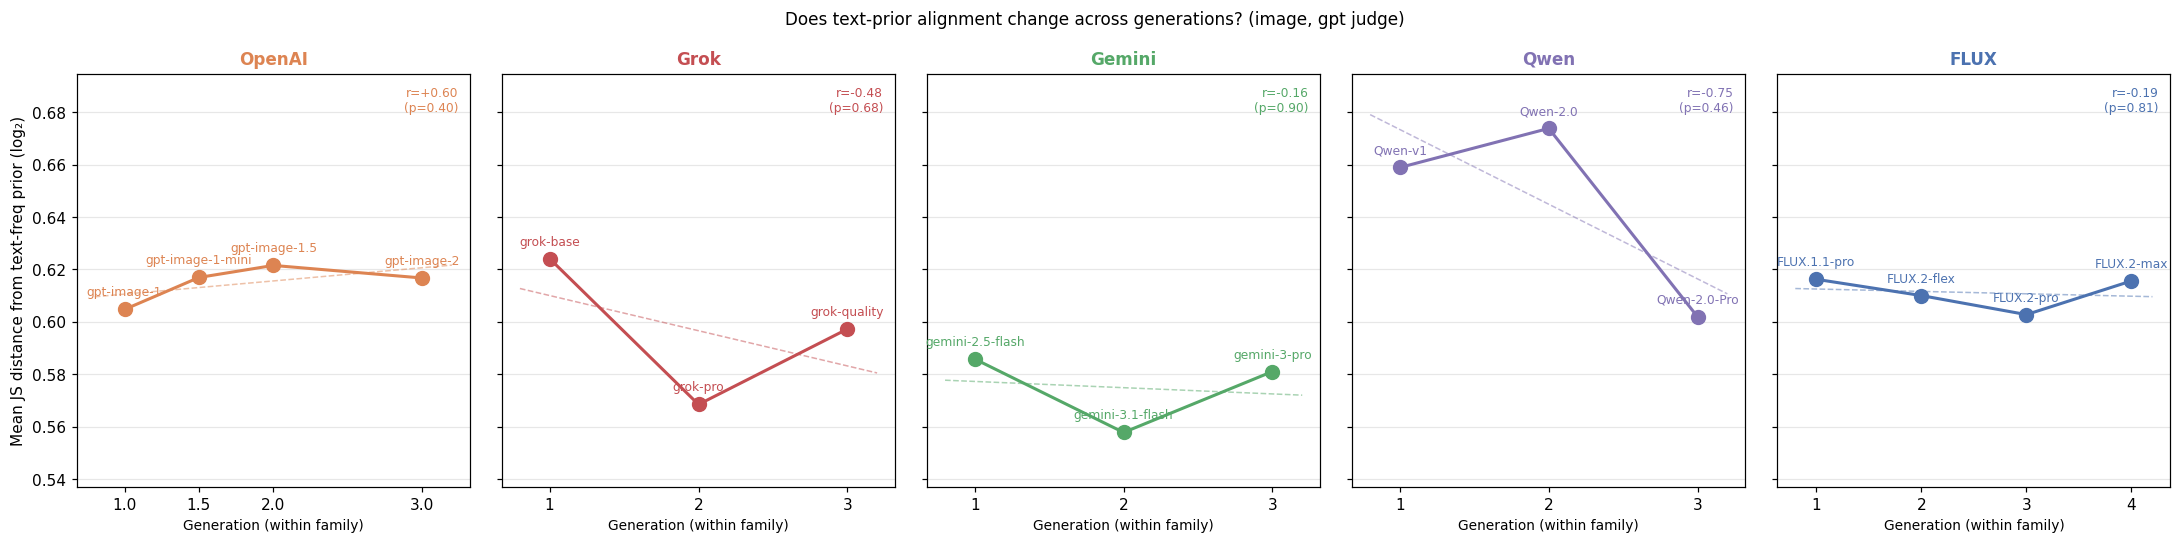

In [15]:
def plot_generation_trend(modality, judge='gpt', prior_name='manual'):
    hist = hist_image if modality == 'image' else hist_text
    freq = freq_manual if prior_name == 'manual' else freq_wiki
    gen_order = registry.generation_order(modality)

    model_js = {}
    for fam, triples in gen_order.items():
        for key, gen, lbl in triples:
            vals = []
            for word, word_data in hist.items():
                if key not in word_data: continue
                vocab = get_vocab(word, word_data, judge)
                tf = text_dist(word, vocab, freq)
                d  = dist_for(word_data[key], vocab, judge)
                if tf is None or d is None: continue
                v = js(tf, d)
                if not np.isnan(v): vals.append(v)
            if vals: model_js[key] = float(np.mean(vals))

    fams = list(gen_order)
    fig, axes = plt.subplots(1, len(fams), figsize=(4 * len(fams), 5), sharey=True)
    if len(fams) == 1: axes = [axes]

    all_gens, all_js_v = [], []
    for ax, fam in zip(axes, fams):
        color = fcolor(fam)
        triples = [(gen, model_js[k], lbl)
                   for k, gen, lbl in gen_order[fam] if k in model_js]
        if not triples: ax.set_visible(False); continue
        gens, jsv, labels = zip(*triples)
        ax.plot(gens, jsv, color=color, lw=2, marker='o', markersize=9, zorder=3)
        for g, j, lbl in zip(gens, jsv, labels):
            ax.text(g, j + 0.004, lbl, ha='center', va='bottom', fontsize=8, color=color)
        if len(set(gens)) >= 3:
            coeffs = np.polyfit(gens, jsv, 1)
            xs = np.linspace(min(gens) - 0.2, max(gens) + 0.2, 50)
            ax.plot(xs, np.polyval(coeffs, xs), color=color, lw=1, ls='--', alpha=0.5)
            r, pv = pearsonr(gens, jsv)
            ax.text(0.97, 0.97, f'r={r:+.2f}\n(p={pv:.2f})', transform=ax.transAxes,
                    ha='right', va='top', fontsize=8, color=color)
        all_gens.extend(gens); all_js_v.extend(jsv)
        ax.set_title(flabel(fam), fontsize=11, fontweight='bold', color=color)
        ax.set_xlabel('Generation (within family)', fontsize=9)
        ax.set_xticks(sorted(set(gens)))
        ax.grid(axis='y', alpha=0.3)

    if all_js_v:
        lo, hi = min(all_js_v), max(all_js_v)
        pad = (hi - lo) * 0.18 or 0.04
        axes[0].set_ylim(lo - pad, hi + pad)
    axes[0].set_ylabel('Mean JS distance from text-freq prior (log₂)')
    fig.suptitle(f'Does text-prior alignment change across generations? ({modality}, {judge} judge)',
                 fontsize=11)
    plt.tight_layout(); plt.show()

print('=== IMAGE: generation trend ===')
plot_generation_trend('image')

=== TEXT: generation trend ===


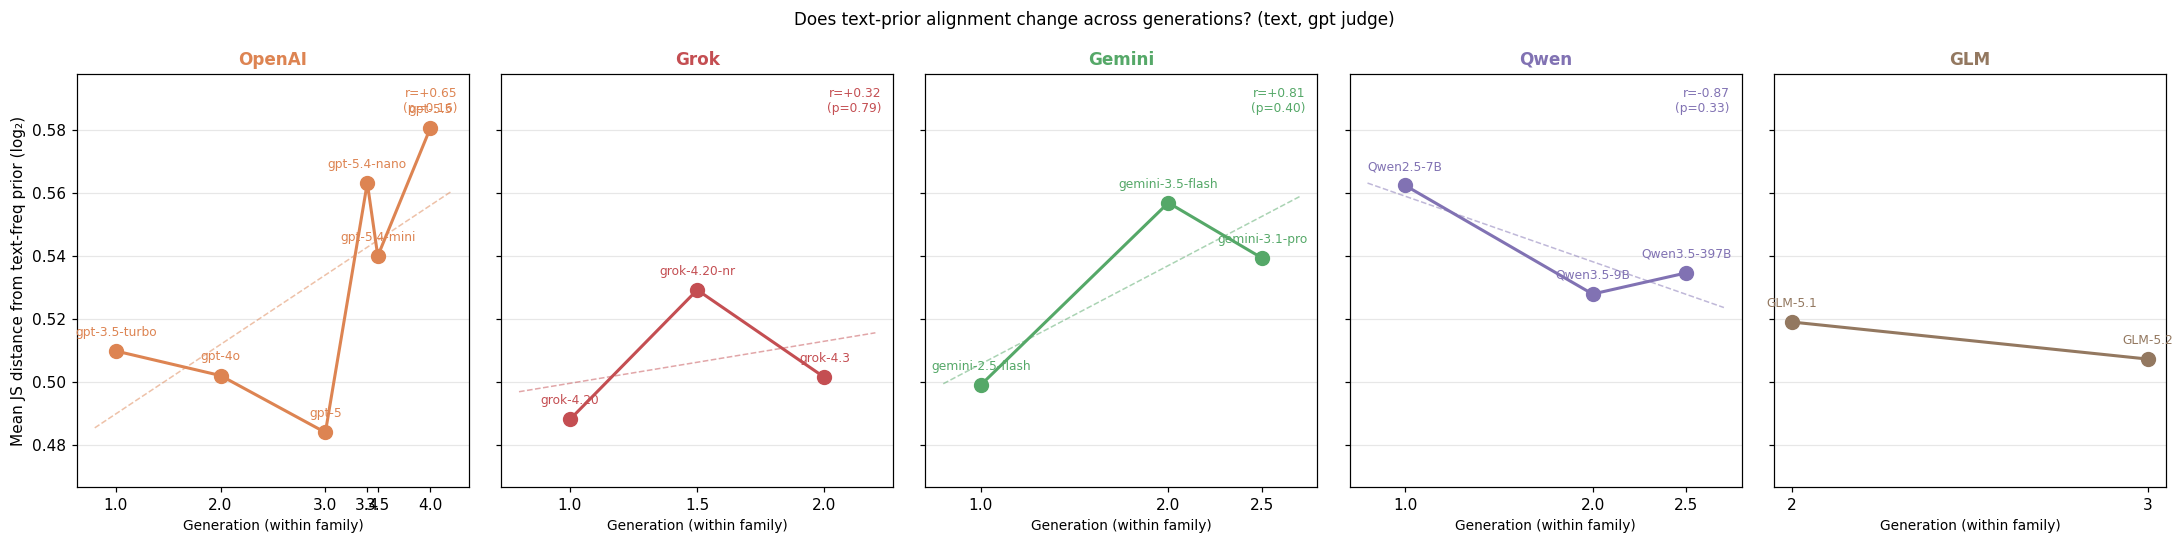

In [16]:
print('=== TEXT: generation trend ===')
plot_generation_trend('text')

## 6. Per-Word Inter-Model Disagreement

For each word, we compute the **mean pairwise JS distance** across all models that have data for that word. High scores mark words where models strongly disagree — i.e., different models pick completely different senses. Low scores mark words where all models converge on the same dominant sense regardless of family.

Words with high disagreement are the most interesting lexical 'battlegrounds' for studying how training data and model architecture shape semantic representations.

=== IMAGE: word disagreement ===


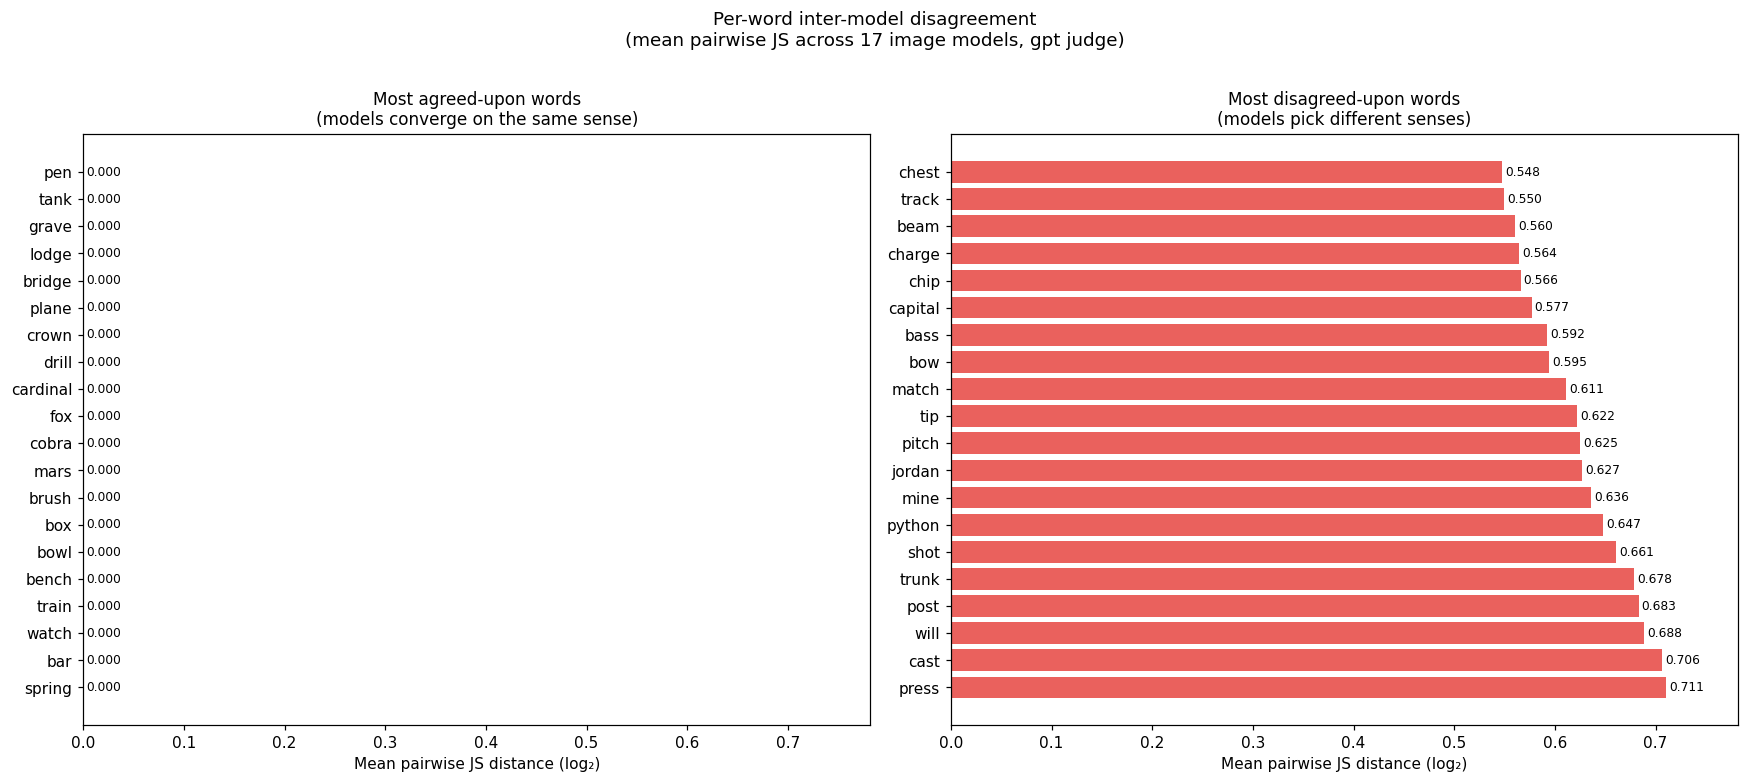

In [17]:
def plot_word_disagreement(modality, judge='gpt', top_n=20):
    hist = hist_image if modality == 'image' else hist_text
    models = IMAGE_MODELS if modality == 'image' else TEXT_MODELS

    word_scores = {}
    for word, word_data in hist.items():
        vocab = get_vocab(word, word_data, judge)
        dists = [d for m in models if m in word_data
                 and (d := dist_for(word_data[m], vocab, judge)) is not None]
        if len(dists) < 2: continue
        word_scores[word] = mean_pairwise_js(dists)

    ranked = sorted(word_scores.items(), key=lambda x: x[1])
    most_sim  = ranked[:top_n]
    most_diff = ranked[-top_n:]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    for ax, items, title, color in [
        (axes[0], most_sim, 'Most agreed-upon words\n(models converge on the same sense)', '#4CAF50'),
        (axes[1], list(reversed(most_diff)), 'Most disagreed-upon words\n(models pick different senses)', '#E53935'),
    ]:
        words  = [w for w, _ in items]
        scores = [s for _, s in items]
        y = np.arange(len(words))
        ax.barh(y, scores, color=color, alpha=0.8)
        ax.set_yticks(y); ax.set_yticklabels(words, fontsize=10)
        ax.set_xlabel('Mean pairwise JS distance (log₂)')
        ax.set_xlim(0, max(word_scores.values()) * 1.1)
        ax.set_title(title, fontsize=11)
        for i, (w, s) in enumerate(items):
            ax.text(s + 0.003, i, f'{s:.3f}', va='center', fontsize=8)

    plt.suptitle(f'Per-word inter-model disagreement\n'
                 f'(mean pairwise JS across {len(models)} {modality} models, {judge} judge)',
                 fontsize=12, y=1.01)
    plt.tight_layout(); plt.show()

    return word_scores

print('=== IMAGE: word disagreement ===')
img_word_scores = plot_word_disagreement('image')

## 7. Cross-Modality Comparison: Image vs Text

All **100 words** have been classified in both modalities, enabling a full comparison. For each word and each model family, we aggregate the family's image-model sense distribution and its text-model distribution over a shared vocabulary, then compute JS distance between the two.

- A **low** score means the family resolves the word the same way whether drawing a picture or writing a sentence — visual and verbal representations are aligned.
- A **high** score means the two modalities diverged — the family's image and text models have learned different dominant senses for the same word.

The second panel ranks words by how much they split image vs text interpretation across all families.


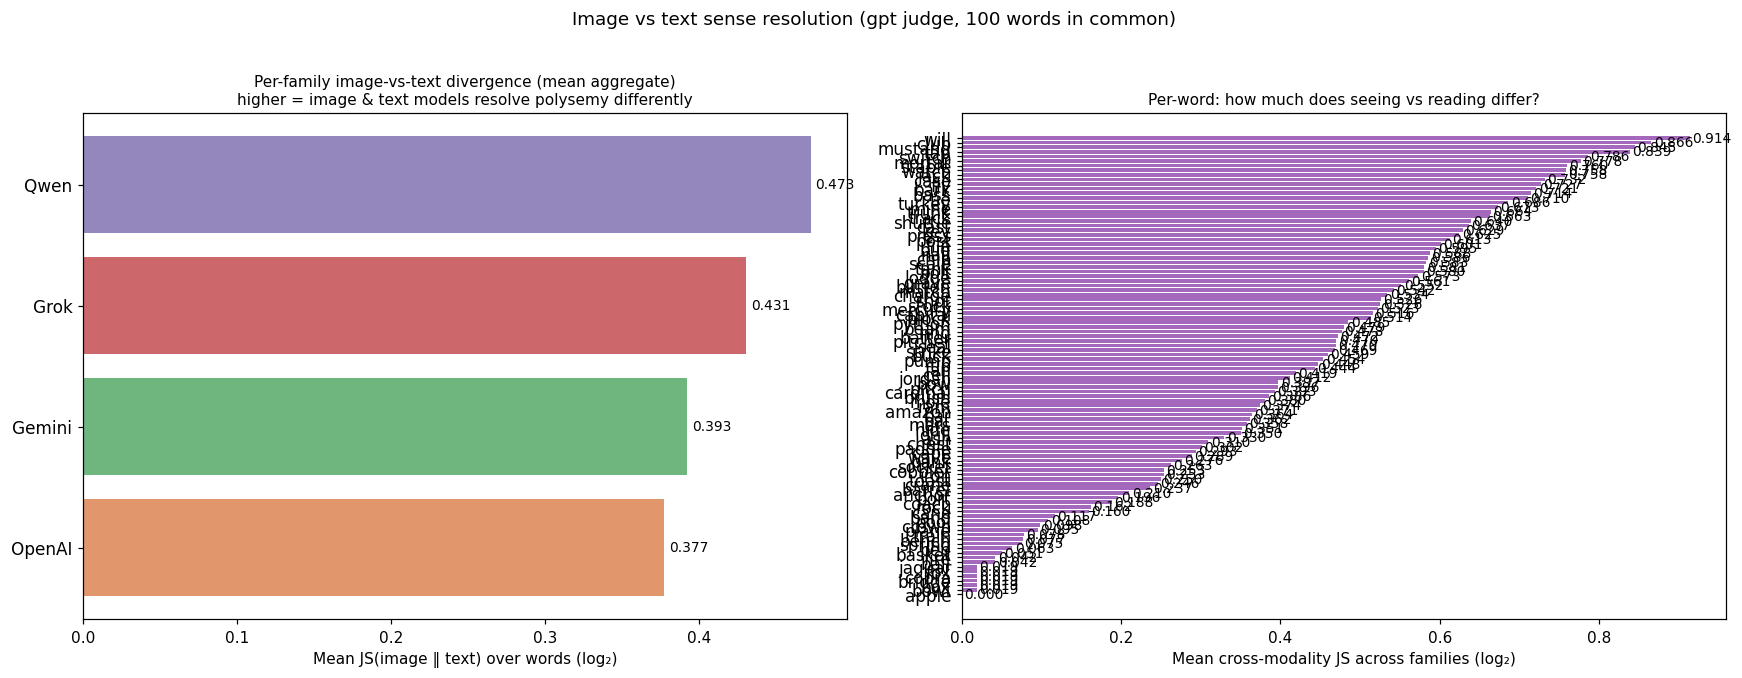

In [18]:
def cross_modality_analysis(judge='gpt', agg='mean'):
    """Two summary panels: per-family and per-word image-vs-text JS distance."""
    if not BOTH_WORDS:
        print('No words with data in both modalities.'); return

    img_groups = registry.family_groups('image')
    txt_groups = registry.family_groups('text')
    fams = [f for f in registry.families('image') if f in registry.families('text')]

    def _agg(word_data, keys, vocab, mode):
        present = [k for k in keys if k in word_data]
        if not present: return None
        if mode == 'latest':
            for k in reversed(present):
                d = dist_for(word_data[k], vocab, judge)
                if d is not None: return d
            return None
        dists = [d for k in present if (d := dist_for(word_data[k], vocab, judge)) is not None]
        if not dists: return None
        m = np.mean(dists, axis=0); s = m.sum()
        return m / s if s > 0 else None

    per_family = {f: [] for f in fams}
    per_word   = {w: [] for w in BOTH_WORDS}

    for word in BOTH_WORDS:
        merged = {**hist_image[word], **hist_text[word]}
        vocab  = get_vocab(word, merged, judge)
        for f in fams:
            img = _agg(hist_image[word], img_groups.get(f, []), vocab, agg)
            txt = _agg(hist_text[word],  txt_groups.get(f, []), vocab, agg)
            if img is None or txt is None: continue
            v = js(img, txt)
            if not np.isnan(v):
                per_family[f].append(v)
                per_word[word].append(v)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Panel 1: per-family
    fam_means = [(f, float(np.mean(v))) for f, v in per_family.items() if v]
    fam_means.sort(key=lambda x: x[1])
    ax = axes[0]
    y = np.arange(len(fam_means))
    ax.barh(y, [m for _, m in fam_means], color=[fcolor(f) for f, _ in fam_means], alpha=0.85)
    ax.set_yticks(y); ax.set_yticklabels([flabel(f) for f, _ in fam_means], fontsize=11)
    ax.set_xlabel('Mean JS(image ‖ text) over words (log₂)')
    ax.set_title(f'Per-family image-vs-text divergence ({agg} aggregate)\n'
                 'higher = image & text models resolve polysemy differently', fontsize=10)
    for i, (f, m) in enumerate(fam_means):
        ax.text(m + 0.003, i, f'{m:.3f}', va='center', fontsize=9)

    # Panel 2: per-word
    word_means = sorted(((w, float(np.mean(v))) for w, v in per_word.items() if v),
                        key=lambda x: x[1])
    ax2 = axes[1]
    y2 = np.arange(len(word_means))
    ax2.barh(y2, [m for _, m in word_means], color='#8E44AD', alpha=0.8)
    ax2.set_yticks(y2); ax2.set_yticklabels([w for w, _ in word_means], fontsize=11)
    ax2.set_xlabel('Mean cross-modality JS across families (log₂)')
    ax2.set_title('Per-word: how much does seeing vs reading differ?', fontsize=10)
    for i, (w, m) in enumerate(word_means):
        ax2.text(m + 0.003, i, f'{m:.3f}', va='center', fontsize=9)

    plt.suptitle(f'Image vs text sense resolution ({judge} judge, {len(BOTH_WORDS)} words in common)',
                 fontsize=12, y=1.02)
    plt.tight_layout(); plt.show()


def plot_cross_word(word, judge='gpt'):
    """Side-by-side image-vs-text sense distributions for a SINGLE word."""
    if word not in hist_image or word not in hist_text:
        print(f'No cross-modality data for "{word}"'); return
    merged = {**hist_image[word], **hist_text[word]}
    vocab = get_vocab(word, merged, judge)
    senses = get_senses(word)
    all_labels = senses + [l for l in ['multiple', 'unclear', 'other'] if l in vocab]
    color_map = sense_colors(senses)

    img_cols = [m for m in IMAGE_MODELS if m in hist_image.get(word, {})]
    txt_cols = [m for m in TEXT_MODELS  if m in hist_text.get(word, {})]
    if not img_cols or not txt_cols:
        print(f'"{word}" is missing one modality.'); return

    all_cols = img_cols + txt_cols
    n_img = len(img_cols)
    x = np.arange(len(all_cols))
    fig, ax = plt.subplots(figsize=(max(12, len(all_cols) * 0.8), 4.5))
    bottoms = np.zeros(len(all_cols))
    for lbl in all_labels:
        idx = vocab.index(lbl) if lbl in vocab else -1
        vals = []
        for m, hist_d in [(m, hist_image) for m in img_cols] + [(m, hist_text) for m in txt_cols]:
            d = dist_for(hist_d[word][m], vocab, judge)
            vals.append(float(d[idx]) if d is not None and idx >= 0 else 0.0)
        vals = np.array(vals)
        if vals.sum() == 0: continue
        ax.bar(x, vals, 0.65, bottom=bottoms,
               color=color_map.get(lbl, '#999'), label=lbl, zorder=3)
        bottoms += vals

    split = n_img - 0.5
    ax.axvline(split, color='black', lw=2, ls='-')
    ax.text(split / 2, 1.03, 'IMAGE models', ha='center', fontsize=9,
            fontweight='bold', transform=ax.get_xaxis_transform())
    ax.text((split + len(all_cols) - 0.5) / 2, 1.03, 'TEXT models',
            ha='center', fontsize=9, fontweight='bold',
            transform=ax.get_xaxis_transform())
    tick_labels = [dlabel(m) for m in img_cols] + [dlabel(m) for m in txt_cols]
    ax.set_xticks(x)
    ax.set_xticklabels(tick_labels, rotation=40, ha='right', fontsize=8)
    ax.set_ylim(0, 1.12); ax.set_ylabel('Proportion')
    ax.set_title(f'"{word}" — image vs text sense distributions ({judge} judge)', fontsize=11)
    ax.legend(loc='upper right', fontsize=8, framealpha=0.8)
    ax.grid(axis='y', alpha=0.3, zorder=0)
    plt.tight_layout(); plt.show()

    print(f'Sense definitions for "{word}":')
    for s in meanings.get(word, []):
        print(f'  {s["sense"]:12s} — {s["meaning"]}')


# Summary panels (always rendered)
cross_modality_analysis()

# ── Per-word side-by-side: ONE word at a time via a dropdown ──────────────────
# (was 100 stacked figures; now interactive so you pick the word you want)
if HAS_WIDGETS:
    _outc = widgets.Output()
    _wordc_w = widgets.Dropdown(options=BOTH_WORDS, value='bank' if 'bank' in BOTH_WORDS else BOTH_WORDS[0],
                                description='Word:', style={'description_width': '80px'})
    _judgec_w = widgets.RadioButtons(options=['gpt', 'gemini', 'consensus'],
                                     description='Judge:', style={'description_width': '80px'})

    def _redrawc(*_):
        _outc.clear_output(wait=True)
        with _outc:
            plot_cross_word(_wordc_w.value, _judgec_w.value)

    for _w in (_wordc_w, _judgec_w):
        _w.observe(_redrawc, names='value')
    display(widgets.VBox([widgets.HBox([_wordc_w, _judgec_w]), _outc]))
    _redrawc()
else:
    # Static fallback: a couple of illustrative words instead of all 100.
    for _w in ('bank', 'trunk', 'mine'):
        if _w in BOTH_WORDS:
            plot_cross_word(_w, 'gpt')

### 7b. Which Modality Is More Diverse? (Shannon Entropy)

The cross-modality charts above measure how *differently* image and text resolve a word. This section asks a different question: **within** each modality, how *decisive* are the models? For every (model, word) we take the model's distribution over the 30 sense-picks and compute its **Shannon entropy** — `0` when the model always picks the same sense, maximal when it splits evenly across senses. Higher entropy = more diverse / less decisive.

To compare fairly across words with different sense counts, entropy is **normalised** to `[0, 1]` (divided by `log₂` of a shared image+text vocabulary per word). We report the mean per modality, an unpaired Mann–Whitney test over all model×word cells, and a **paired** test across the 100 shared words (each word contributes its image-model mean vs its text-model mean, controlling for how intrinsically ambiguous the word is).

=== Modality diversity: normalised Shannon entropy (0 = decisive, 1 = uniform) ===

  IMAGE : mean=0.123  median=0.000  (n=1698 model x word cells, 17 models)
  TEXT  : mean=0.207  median=0.154  (n=1700 model x word cells, 17 models)

  -> TEXT models are MORE diverse (higher entropy) on average.

  Mann-Whitney U (all cells, two-sided): U=1076045, p=5.89e-43

  Paired across 100 shared words (image-mean vs text-mean):
    mean diff (image - text) = -0.084
    paired t-test:  t=-5.95, p=4.14e-08
    Wilcoxon:       W=1028, p=2.64e-07
    image > text on 28/100 words


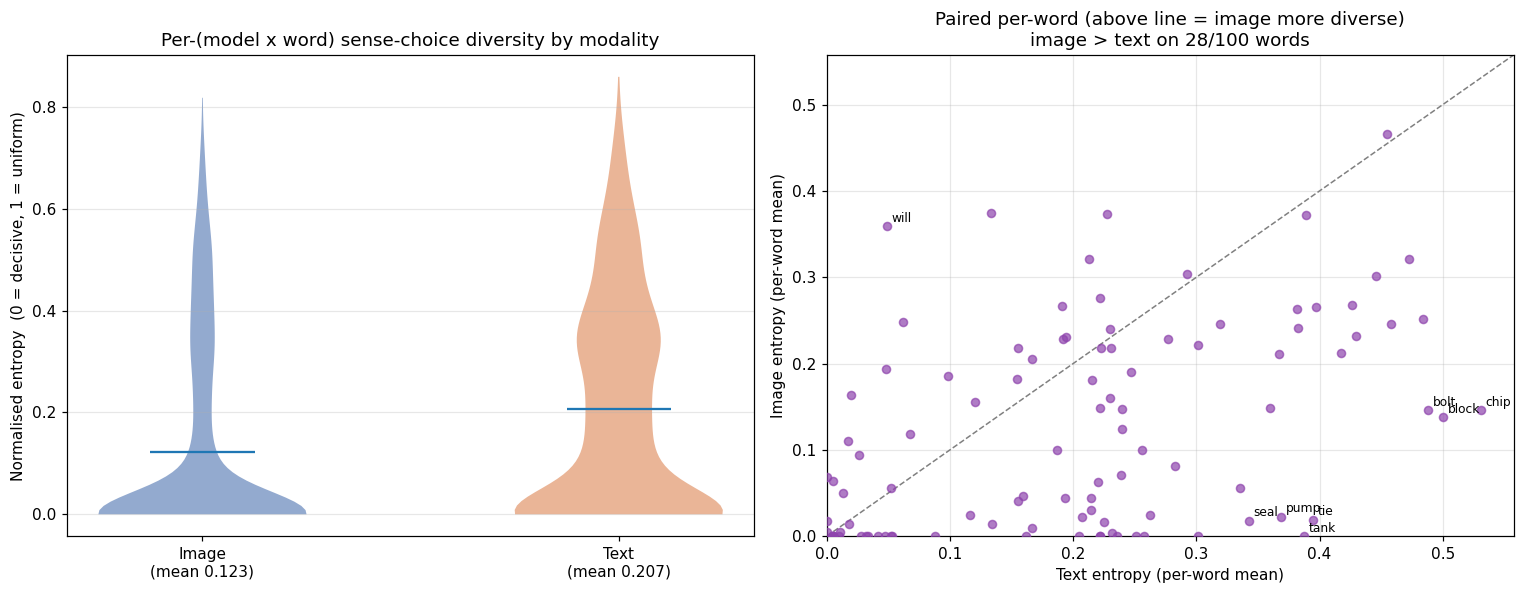

In [19]:
# ── Which modality is more diverse?  (Shannon entropy of sense choices) ──────
# Diversity = how spread-out a model's 30 sense-picks are for a word:
#   entropy 0        -> always the same sense  (decisive)
#   entropy log2(k)  -> evenly split across k senses  (maximally diverse)
# Per word we build a SHARED vocab (image+text merged) and report NORMALISED
# entropy = H / log2(|vocab|) in [0, 1], so words with different sense counts
# are comparable across modalities. Judge = gpt (matches the rest of the notebook).
from scipy.stats import ttest_rel, wilcoxon, mannwhitneyu

JUDGE = 'gpt'

def modality_entropy_cells(normalise=True):
    """{modality: [(word, model, H), ...]} — one entropy per (model, word) cell."""
    out = {'image': [], 'text': []}
    for word in BOTH_WORDS:
        merged = {**hist_image[word], **hist_text[word]}
        vocab  = get_vocab(word, merged, JUDGE)
        denom  = np.log2(len(vocab)) if normalise and len(vocab) > 1 else 1.0
        for modality, hist, models in [('image', hist_image, IMAGE_MODELS),
                                       ('text',  hist_text,  TEXT_MODELS)]:
            wd = hist.get(word, {})
            for m in models:
                if m not in wd:
                    continue
                d = dist_for(wd[m], vocab, JUDGE)
                if d is None:
                    continue
                H = entropy(d)
                if not np.isnan(H):
                    out[modality].append((word, m, H / denom))
    return out

cells = modality_entropy_cells(normalise=True)
img_H = np.array([h for _, _, h in cells['image']])
txt_H = np.array([h for _, _, h in cells['text']])

# Per-word means -> paired across the 100 shared words (controls for word difficulty)
def per_word_means(triples):
    d = {}
    for w, _, h in triples:
        d.setdefault(w, []).append(h)
    return {w: float(np.mean(v)) for w, v in d.items()}

img_w, txt_w = per_word_means(cells['image']), per_word_means(cells['text'])
paired_words = [w for w in BOTH_WORDS if w in img_w and w in txt_w]
img_pw = np.array([img_w[w] for w in paired_words])
txt_pw = np.array([txt_w[w] for w in paired_words])
diff   = img_pw - txt_pw

print('=== Modality diversity: normalised Shannon entropy (0 = decisive, 1 = uniform) ===\n')
print(f'  IMAGE : mean={img_H.mean():.3f}  median={np.median(img_H):.3f}  '
      f'(n={img_H.size} model x word cells, {len(IMAGE_MODELS)} models)')
print(f'  TEXT  : mean={txt_H.mean():.3f}  median={np.median(txt_H):.3f}  '
      f'(n={txt_H.size} model x word cells, {len(TEXT_MODELS)} models)')
more = 'IMAGE' if img_H.mean() > txt_H.mean() else 'TEXT'
print(f'\n  -> {more} models are MORE diverse (higher entropy) on average.\n')

u, p_u = mannwhitneyu(img_H, txt_H, alternative='two-sided')
print(f'  Mann-Whitney U (all cells, two-sided): U={u:.0f}, p={p_u:.2e}')

t, p_t = ttest_rel(img_pw, txt_pw)
w_stat, p_w = wilcoxon(img_pw, txt_pw)
print(f'\n  Paired across {len(paired_words)} shared words (image-mean vs text-mean):')
print(f'    mean diff (image - text) = {diff.mean():+.3f}')
print(f'    paired t-test:  t={t:+.2f}, p={p_t:.2e}')
print(f'    Wilcoxon:       W={w_stat:.0f}, p={p_w:.2e}')
print(f'    image > text on {int((diff > 0).sum())}/{len(paired_words)} words')

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
parts = ax.violinplot([img_H, txt_H], showmeans=True, showextrema=False)
for pc, c in zip(parts['bodies'], ['#4C72B0', '#DD8452']):
    pc.set_facecolor(c); pc.set_alpha(0.6)
ax.set_xticks([1, 2])
ax.set_xticklabels([f'Image\n(mean {img_H.mean():.3f})', f'Text\n(mean {txt_H.mean():.3f})'])
ax.set_ylabel('Normalised entropy  (0 = decisive, 1 = uniform)')
ax.set_title('Per-(model x word) sense-choice diversity by modality')
ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
ax2.scatter(txt_pw, img_pw, s=28, alpha=0.7, color='#8E44AD', zorder=3)
lim = [0, max(img_pw.max(), txt_pw.max()) * 1.05]
ax2.plot(lim, lim, ls='--', color='gray', lw=1)
ax2.set_xlim(lim); ax2.set_ylim(lim)
ax2.set_xlabel('Text entropy (per-word mean)')
ax2.set_ylabel('Image entropy (per-word mean)')
ax2.set_title(f'Paired per-word (above line = image more diverse)\n'
              f'image > text on {int((diff > 0).sum())}/{len(paired_words)} words')
for w in sorted(paired_words, key=lambda w: -abs(img_w[w] - txt_w[w]))[:8]:
    ax2.annotate(w, (txt_w[w], img_w[w]), fontsize=8,
                 xytext=(3, 3), textcoords='offset points')
ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

=== Per-family sense-choice diversity (normalised Shannon entropy) ===
    higher = more diverse / less decisive;  Text − Image > 0 => text more diverse



,Family,Image mean,Image n,Text mean,Text n,Text − Image,p (img vs txt)
0,OpenAI,0.070,400,0.199,600,+0.129,6.9e-30
1,Grok,0.089,300,0.257,300,+0.168,7.9e-25
2,Gemini,0.139,300,0.196,300,+0.057,8.5e-05
3,Qwen,0.162,300,0.180,300,+0.018,7.7e-02
4,FLUX,0.160,398,—,0,—,—
5,GLM,—,0,0.211,200,—,—


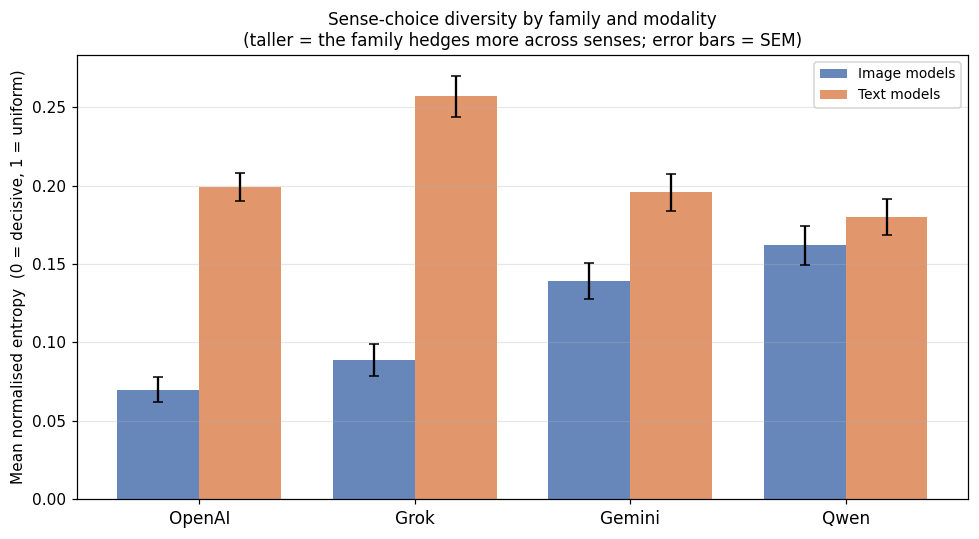

In [20]:
# ── Per-family diversity breakdown (reuses `cells` from the cell above) ──────
# For each provider family, how decisive are its image models vs its text models?
from scipy.stats import mannwhitneyu

def family_entropy(triples):
    """{family: np.array of normalised entropies} from [(word, model, H), ...]."""
    d = {}
    for _, m, h in triples:
        d.setdefault(family_of(m), []).append(h)
    return {f: np.array(v) for f, v in d.items()}

fam_img = family_entropy(cells['image'])
fam_txt = family_entropy(cells['text'])

rows = []
for fam in FAMILY_ORDER:
    i = fam_img.get(fam); t = fam_txt.get(fam)
    row = {'Family': flabel(fam)}
    row['Image mean'] = f'{i.mean():.3f}' if i is not None else '—'
    row['Image n']    = i.size if i is not None else 0
    row['Text mean']  = f'{t.mean():.3f}' if t is not None else '—'
    row['Text n']     = t.size if t is not None else 0
    if i is not None and t is not None:
        _, p = mannwhitneyu(i, t, alternative='two-sided')
        row['Text − Image'] = f'{t.mean() - i.mean():+.3f}'
        row['p (img vs txt)'] = f'{p:.1e}'
    else:
        row['Text − Image'] = '—'; row['p (img vs txt)'] = '—'
    rows.append(row)

df_fam = pd.DataFrame(rows)
print('=== Per-family sense-choice diversity (normalised Shannon entropy) ===')
print('    higher = more diverse / less decisive;  Text − Image > 0 => text more diverse\n')
display(df_fam)

# ── Grouped bar chart: image vs text mean entropy per family ────────────────
fams_both = [f for f in FAMILY_ORDER if f in fam_img and f in fam_txt]
x = np.arange(len(fams_both)); bw = 0.38
fig, ax = plt.subplots(figsize=(9, 5))

def sem(a):  # standard error of the mean
    return a.std(ddof=1) / np.sqrt(a.size) if a.size > 1 else 0.0

img_means = [fam_img[f].mean() for f in fams_both]
txt_means = [fam_txt[f].mean() for f in fams_both]
img_err   = [sem(fam_img[f]) for f in fams_both]
txt_err   = [sem(fam_txt[f]) for f in fams_both]

ax.bar(x - bw/2, img_means, bw, yerr=img_err, capsize=3,
       color='#4C72B0', alpha=0.85, label='Image models')
ax.bar(x + bw/2, txt_means, bw, yerr=txt_err, capsize=3,
       color='#DD8452', alpha=0.85, label='Text models')
ax.set_xticks(x); ax.set_xticklabels([flabel(f) for f in fams_both], fontsize=11)
ax.set_ylabel('Mean normalised entropy  (0 = decisive, 1 = uniform)')
ax.set_title('Sense-choice diversity by family and modality\n'
             '(taller = the family hedges more across senses; error bars = SEM)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

### 7c. Human Baseline: Are People More Diverse Than the Models? (Shannon Entropy)

§7b measured diversity *within* the models. Here we drop in the **human Prolific baseline** (same 100-word English panel, judged by the same GPT + Gemini) and ask how decisive *people* are by comparison. The two human conditions map onto the two modalities: **`meaning`** (participants used the word in a sentence ≈ the *text* models) and **`image`** (participants described the image it evokes ≈ the *image* models). Each word contributes one pooled human distribution (~14 responses); we use the same normalised entropy `H / log₂|vocab|` as above (judge = gpt).

**What to look for:**
- Humans sit *far* higher on the entropy axis than either model modality — people spread across senses where models lock onto one dominant reading (~2–4× the entropy).
- The model ordering (text > image diversity) does **not** carry over to humans, suggesting "image makes you more decisive" is a model artifact, not a human one.
- Caveat: the human distribution pools ~14 *different people* (between-subject) vs a model's 30 within-model samples, and the plug-in entropy estimator is biased *down* at small n — so the human–model gap is, if anything, conservative.

=== Sense diversity: humans vs models  (normalised Shannon entropy, judge=gpt, 100 words) ===
    0 = always one sense (decisive) .. 1 = evenly split (diverse)

source              mean     std
LLM text           0.207   0.145
LLM image          0.123   0.119
Human meaning      0.423   0.229
Human image        0.476   0.203

=== paired across shared words (Wilcoxon) ===
  Human meaning  vs LLM text  : 0.423 vs 0.207  (diff +0.216, p=2.3e-15, n=100)
  Human image    vs LLM image : 0.476 vs 0.123  (diff +0.353, p=1.0e-17, n=100)
  Human meaning  vs Human image: 0.423 vs 0.476  (diff -0.054, p=8.5e-03, n=100)


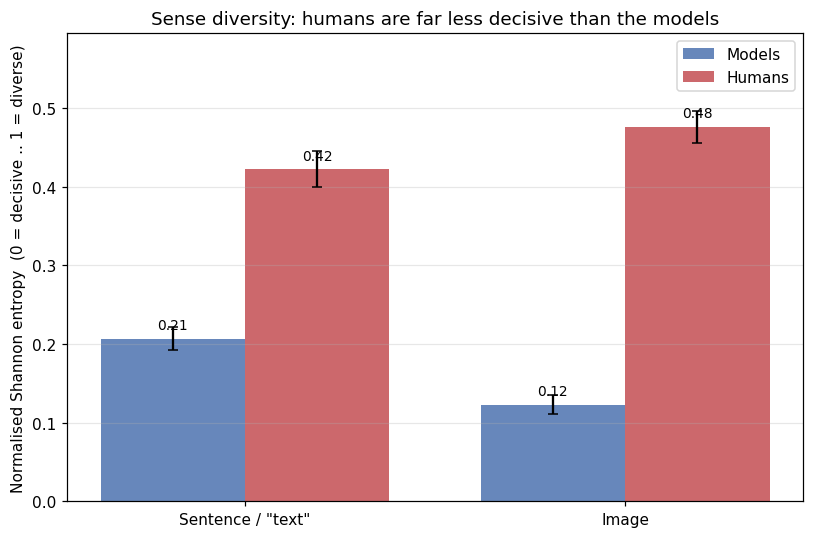

In [21]:
# ── Human baseline: sense diversity vs the models (normalised Shannon entropy) ─
# Humans = the Prolific responses, judged by the same GPT+Gemini, in two conditions:
#   meaning (used the word in a sentence) ~ text models
#   image   (described the image it evokes) ~ image models
# Same metric as 7b: per word, H / log2(|vocab|) in [0,1]; judge = gpt. Reuses the
# get_vocab / dist_for / entropy helpers (Setup) and hist_image/hist_text (§1).
from scipy.stats import wilcoxon

hist_hm = json.load(open('data/histograms_human_meaning.json'))
hist_hi = json.load(open('data/histograms_human_image.json'))
HUMAN_WORDS = [w for w in BOTH_WORDS if w in hist_hm and w in hist_hi]

def _norm_entropy_per_word(hist, model_keys):
    """word -> mean normalised entropy across the given cells (judge = gpt)."""
    out = {}
    for w in HUMAN_WORDS:
        merged = {**hist_image.get(w, {}), **hist_text.get(w, {}),
                  **hist_hm.get(w, {}), **hist_hi.get(w, {})}
        vocab = get_vocab(w, merged, 'gpt')
        denom = np.log2(len(vocab)) if len(vocab) > 1 else 1.0
        wd, vals = hist.get(w, {}), []
        for m in model_keys:
            if m not in wd:
                continue
            d = dist_for(wd[m], vocab, 'gpt')
            if d is None:
                continue
            h = entropy(d)
            if not np.isnan(h):
                vals.append(h / denom)
        if vals:
            out[w] = float(np.mean(vals))
    return out

ent = {
    'LLM text':      _norm_entropy_per_word(hist_text,  TEXT_MODELS),
    'LLM image':     _norm_entropy_per_word(hist_image, IMAGE_MODELS),
    'Human meaning': _norm_entropy_per_word(hist_hm,    ['human']),
    'Human image':   _norm_entropy_per_word(hist_hi,    ['human']),
}

print(f'=== Sense diversity: humans vs models  (normalised Shannon entropy, judge=gpt, {len(HUMAN_WORDS)} words) ===')
print('    0 = always one sense (decisive) .. 1 = evenly split (diverse)\n')
print(f"{'source':16s}{'mean':>8s}{'std':>8s}")
for name, d in ent.items():
    a = np.array(list(d.values()))
    print(f'{name:16s}{a.mean():>8.3f}{a.std(ddof=1):>8.3f}')

def _paired(aN, bN):
    a, b = ent[aN], ent[bN]
    ws = [w for w in HUMAN_WORDS if w in a and w in b]
    av = np.array([a[w] for w in ws]); bv = np.array([b[w] for w in ws])
    return av.mean(), bv.mean(), wilcoxon(av, bv)[1], len(ws)

print('\n=== paired across shared words (Wilcoxon) ===')
for aN, bN in [('Human meaning', 'LLM text'), ('Human image', 'LLM image'),
               ('Human meaning', 'Human image')]:
    ma, mb, p, n = _paired(aN, bN)
    print(f'  {aN:14s} vs {bN:10s}: {ma:.3f} vs {mb:.3f}  (diff {ma - mb:+.3f}, p={p:.1e}, n={n})')

# ── grouped bars: model vs human, by condition ──
def _sem(a): return a.std(ddof=1) / np.sqrt(a.size) if a.size > 1 else 0.0
conds = [('Sentence / "text"', 'LLM text', 'Human meaning'),
         ('Image', 'LLM image', 'Human image')]
labels  = [c[0] for c in conds]
model_m = [np.mean(list(ent[c[1]].values())) for c in conds]
human_m = [np.mean(list(ent[c[2]].values())) for c in conds]
model_e = [_sem(np.array(list(ent[c[1]].values()))) for c in conds]
human_e = [_sem(np.array(list(ent[c[2]].values()))) for c in conds]

x = np.arange(len(labels)); bw = 0.38
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.bar(x - bw / 2, model_m, bw, yerr=model_e, capsize=3, color='#4C72B0', alpha=0.85, label='Models')
ax.bar(x + bw / 2, human_m, bw, yerr=human_e, capsize=3, color='#C44E52', alpha=0.85, label='Humans')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Normalised Shannon entropy  (0 = decisive .. 1 = diverse)')
ax.set_title('Sense diversity: humans are far less decisive than the models')
ax.set_ylim(0, max(human_m) * 1.25); ax.legend(); ax.grid(axis='y', alpha=0.3)
for xi, (mm, hm) in enumerate(zip(model_m, human_m)):
    ax.text(xi - bw / 2, mm + 0.012, f'{mm:.2f}', ha='center', fontsize=9)
    ax.text(xi + bw / 2, hm + 0.012, f'{hm:.2f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

### 7d. Does Sense Diversity Collapse Across Model Generations?

§7b/§7c compared modalities and the human baseline at a single point in time. Here we ask whether **sense diversity shrinks as models get newer** — i.e. do later generations collapse harder onto one dominant sense? Each model's mean normalised entropy (judge = gpt) is plotted against its `generation_index` (registry; 1 = oldest) within each modality, joined per provider family. The dashed red line is the human baseline for the matching condition.

**What to look for:**
- **Text:** a clear downward slope — newer text models are *less* diverse (Spearman ρ ≈ −0.6, p ≈ 0.02), and **all four families decline** from oldest to newest. They collapse *away* from the human baseline over time.
- **Image:** flat (ρ not significant) — image models are already near the entropy floor from generation 1, so there is no room to collapse further.

Caveat: n is small (15 text / 17 image models) and `generation_index` is a coarse cross-family ordering — read the per-family monotonic decline as the stronger evidence and the pooled ρ as suggestive.

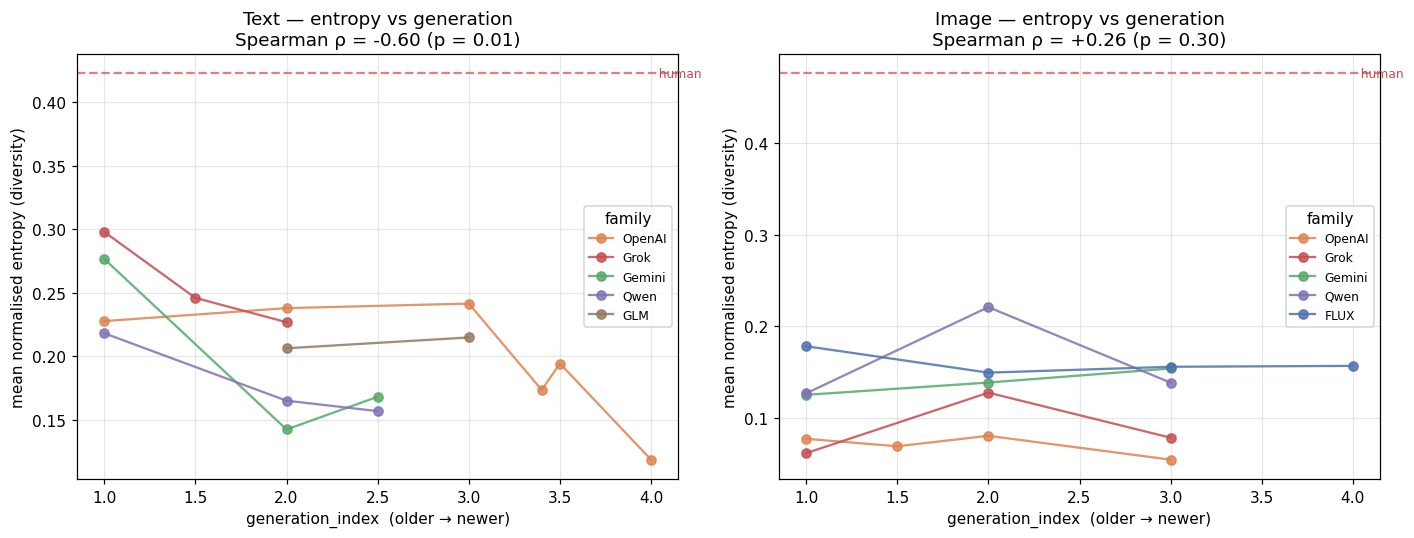

=== entropy vs generation_index  (negative => newer models more collapsed) ===
  text  : Spearman rho=-0.60 (p=0.01)   Pearson r=-0.63 (p=0.01)   n=17
          within-family newest-oldest: OpenAI -0.109  Grok -0.071  Gemini -0.108  Qwen -0.061  GLM +0.009
  image : Spearman rho=+0.26 (p=0.30)   Pearson r=+0.15 (p=0.56)   n=17
          within-family newest-oldest: OpenAI -0.023  Grok +0.017  Gemini +0.029  Qwen +0.012  FLUX -0.021


In [22]:
# ── Does sense diversity collapse across generations? entropy vs generation ──
# Per model: mean normalised entropy (judge=gpt) vs registry generation_index,
# within each modality, joined per family. Negative slope => newer = more decisive.
# Reuses get_vocab/dist_for/entropy (Setup), hist_*/{TEXT,IMAGE}_MODELS (§1), and
# `ent` (§7c) for the human baseline reference line.
from collections import defaultdict
from scipy.stats import spearmanr, pearsonr

def _model_mean_entropy(hist, model):
    vals = []
    for w in BOTH_WORDS:
        vocab = get_vocab(w, {**hist_image.get(w, {}), **hist_text.get(w, {})}, 'gpt')
        denom = np.log2(len(vocab)) if len(vocab) > 1 else 1.0
        wd = hist.get(w, {})
        if model in wd:
            d = dist_for(wd[model], vocab, 'gpt')
            if d is not None:
                h = entropy(d)
                if not np.isnan(h):
                    vals.append(h / denom)
    return float(np.mean(vals)) if vals else np.nan

_gen = lambda k: registry.MODELS[k].generation_index
_modlist = {'text': (hist_text, TEXT_MODELS, 'Human meaning'),
            'image': (hist_image, IMAGE_MODELS, 'Human image')}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, mod in zip(axes, ['text', 'image']):
    hist, models, human_key = _modlist[mod]
    pts = [(k, _gen(k), family_of(k), _model_mean_entropy(hist, k)) for k in models]
    pts = [p for p in pts if not np.isnan(p[3])]
    g = np.array([p[1] for p in pts]); e = np.array([p[3] for p in pts])
    rho, prho = spearmanr(g, e)
    byf = defaultdict(list)
    for k, gi, f, me in pts:
        byf[f].append((gi, me))
    for f in FAMILY_ORDER:
        if f in byf:
            s = sorted(byf[f])
            ax.plot([a for a, _ in s], [b for _, b in s], '-o', ms=6, alpha=0.85,
                    color=FAMILY_COLOR.get(f, 'gray'), label=FAMILY_DISPLAY.get(f, f))
    base = float(np.mean(list(ent[human_key].values())))
    ax.axhline(base, ls='--', color='#C44E52', alpha=0.7)
    ax.text(g.max(), base, '  human', color='#C44E52', va='center', fontsize=8)
    ax.set_title(f'{mod.capitalize()} — entropy vs generation\nSpearman ρ = {rho:+.2f} (p = {prho:.2f})')
    ax.set_xlabel('generation_index  (older → newer)')
    ax.set_ylabel('mean normalised entropy (diversity)')
    ax.grid(alpha=0.3); ax.legend(fontsize=8, title='family')
plt.tight_layout(); plt.show()

print('=== entropy vs generation_index  (negative => newer models more collapsed) ===')
for mod in ['text', 'image']:
    hist, models, _ = _modlist[mod]
    pts = [(_gen(k), _model_mean_entropy(hist, k)) for k in models]
    pts = [p for p in pts if not np.isnan(p[1])]
    g = np.array([a for a, _ in pts]); e = np.array([b for _, b in pts])
    rho, p = spearmanr(g, e); r, pp = pearsonr(g, e)
    print(f'  {mod:6s}: Spearman rho={rho:+.2f} (p={p:.2f})   Pearson r={r:+.2f} (p={pp:.2f})   n={len(pts)}')
    # within-family newest-minus-oldest delta
    byf = defaultdict(list)
    for k in models:
        me = _model_mean_entropy(hist, k)
        if not np.isnan(me): byf[family_of(k)].append((_gen(k), me))
    deltas = {f: sorted(v)[-1][1] - sorted(v)[0][1] for f, v in byf.items() if len(v) >= 2}
    print('          within-family newest-oldest: ' +
          '  '.join(f'{FAMILY_DISPLAY.get(f, f)} {d:+.3f}' for f, d in deltas.items()))

### 7e. Superposition: Does FLUX Produce "multiple" More Than Other Families?

A `multiple` label means the judge saw **two or more senses at once** in a single output — the "superposition" behaviour that the README hypothesises is diffusion-bound (FLUX is the only confirmed-diffusion family, and the only image-only one). Here we test whether FLUX's `multiple` rate exceeds the other image families'.

Two tests, because the unit of analysis matters:
- **Sample-level** 2×2 (Fisher exact / χ²) — every generated image is a trial. Powerful but **anti-conservative**: the 30 samples from one model aren't independent, so the p-value is inflated. Report descriptively.
- **Model-level** Mann–Whitney — each model contributes one `multiple`-rate; FLUX models vs all other image models. This respects model as the unit and is the honest significance test.

In [23]:
# ── Is FLUX's "multiple" (superposition) rate higher than other families? ────
from scipy.stats import fisher_exact, chi2_contingency, mannwhitneyu
from collections import defaultdict

JUDGE = 'gpt'  # primary judge; '_counts' aggregates the 30 samples per (word, model)

mult, tot, model_rate = defaultdict(int), defaultdict(int), {}
for word, models in hist_image.items():
    for mk, md in models.items():
        node = md.get(JUDGE) or next((v for k, v in md.items() if k != '_agreement'), None)
        if not node:
            continue
        c = node.get('_counts', {}); n = sum(c.values())
        if n == 0:
            continue
        mult[mk] += c.get('multiple', 0); tot[mk] += n
for mk in tot:
    model_rate[mk] = mult[mk] / tot[mk]

fam_mult, fam_tot, fam_rates = defaultdict(int), defaultdict(int), defaultdict(list)
for mk in tot:
    f = family_of(mk)
    fam_mult[f] += mult[mk]; fam_tot[f] += tot[mk]; fam_rates[f].append(model_rate[mk])

print("=== 'multiple' (superposition) rate by image family — gpt judge ===\n")
order = sorted(registry.families('image'), key=lambda f: -fam_mult[f] / fam_tot[f])
for f in order:
    print(f"  {flabel(f):7} {fam_mult[f]:5}/{fam_tot[f]:5} = {fam_mult[f]/fam_tot[f]:6.2%}   ({len(fam_rates[f])} models)")

flux_m, flux_t = fam_mult['flux'], fam_tot['flux']
oth_m = sum(v for f, v in fam_mult.items() if f != 'flux')
oth_t = sum(v for f, v in fam_tot.items() if f != 'flux')
print(f"\n  FLUX  : {flux_m}/{flux_t} = {flux_m/flux_t:.2%}")
print(f"  OTHER : {oth_m}/{oth_t} = {oth_m/oth_t:.2%}")
print(f"  ratio : {(flux_m/flux_t)/(oth_m/oth_t):.1f}x")

# Sample-level (anti-conservative: samples within a model are not independent)
table = [[flux_m, flux_t - flux_m], [oth_m, oth_t - oth_m]]
OR, p_fish = fisher_exact(table, alternative='greater')
chi2, p_chi, _, _ = chi2_contingency(table)
print(f"\n  [sample-level 2x2]  Fisher exact (FLUX>other): OR={OR:.1f}, p={p_fish:.2e}")
print(f"                      chi-square: chi2={chi2:.0f}, p={p_chi:.2e}  (treat as descriptive)")

# Model-level (honest test: model = unit of analysis)
flux_rates = fam_rates['flux']
oth_rates = [r for f in fam_rates if f != 'flux' for r in fam_rates[f]]
u, p_mwu = mannwhitneyu(flux_rates, oth_rates, alternative='greater')
print(f"\n  [model-level]  FLUX n={len(flux_rates)}  rates={[f'{r:.1%}' for r in flux_rates]}")
print(f"                 other n={len(oth_rates)}  median={np.median(oth_rates):.2%}")
print(f"                 Mann-Whitney U (FLUX>other, one-sided): U={u:.0f}, p={p_mwu:.4f} "
      f"{'(significant)' if p_mwu < 0.05 else '(n.s.)'}")

# ── Plot: per-model multiple rate, coloured by family, FLUX highlighted ──────
keys = [k for k in registry.models_for('image') if k in model_rate]
vals = [model_rate[k] for k in keys]
cols = [('#4C72B0' if family_of(k) == 'flux' else '#BBBBBB') for k in keys]
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(np.arange(len(keys)), vals, color=cols, edgecolor='white', linewidth=0.5)
ax.axhline(oth_m / oth_t, color='#C44E52', ls='--', lw=1, label=f'non-FLUX mean ({oth_m/oth_t:.2%})')
ax.set_xticks(np.arange(len(keys)))
ax.set_xticklabels([dlabel(k) for k in keys], rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Fraction of samples labelled 'multiple'")
ax.set_title(f"Superposition rate by image model  —  FLUX {flux_m/flux_t:.1%} vs others {oth_m/oth_t:.1%} "
             f"({(flux_m/flux_t)/(oth_m/oth_t):.1f}x; model-level p={p_mwu:.3f})", fontsize=11)
ax.legend(handles=[Patch(color='#4C72B0', label='FLUX (diffusion)'),
                   Patch(color='#BBBBBB', label='other families')] +
                  [plt.Line2D([0],[0], color='#C44E52', ls='--', label=f'non-FLUX mean')],
          fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 8. Model Geometry: PCA of Sense Distributions

Each model can be represented as a long feature vector: concatenate its per-word sense distributions across all words into a single vector. PCA then projects these high-dimensional vectors into 2D, preserving as much variance as possible.

Models that cluster together in the PCA biplot resolve polysemy similarly. Models that lie far apart have genuinely different 'views' of what ambiguous words mean.

Lines connect consecutive generations within each family, making generational drift visible as a trajectory in sense-space.

=== IMAGE PCA ===


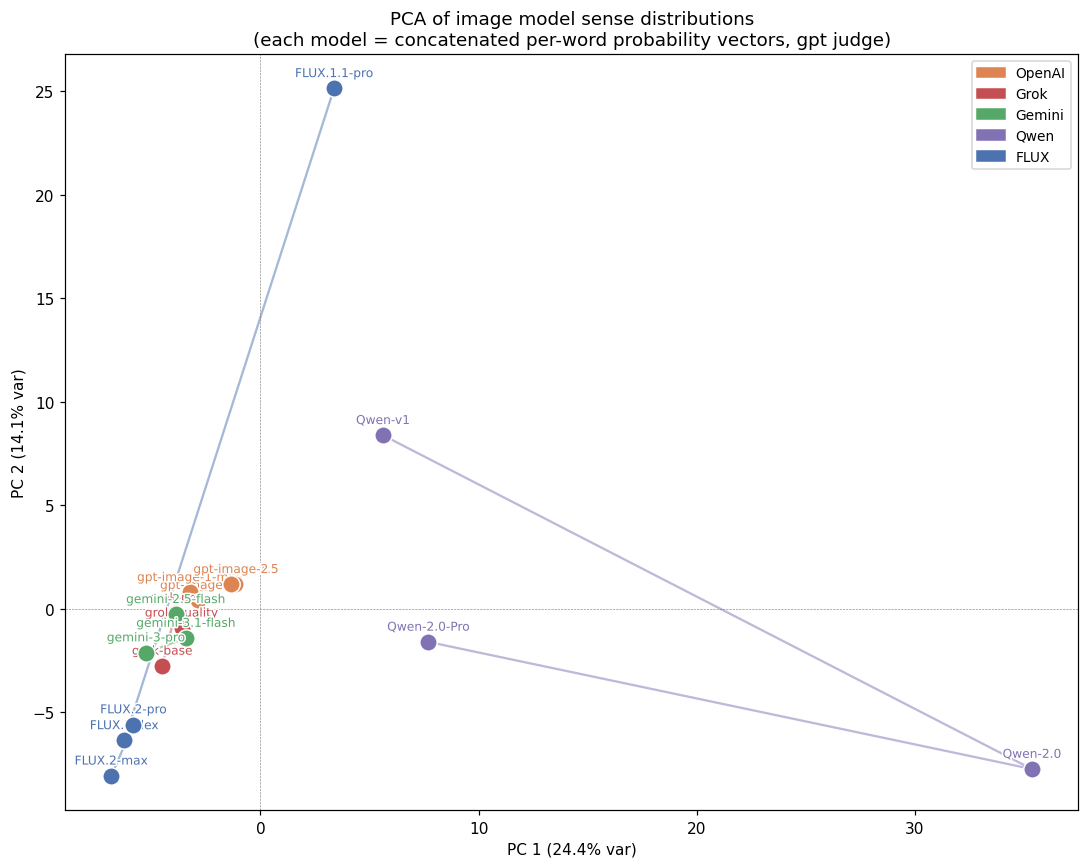

PCA variance explained: PC1=24.4%, PC2=14.1%


In [ ]:
def plot_pca(modality, judge='gpt'):
    hist = hist_image if modality == 'image' else hist_text
    models = IMAGE_MODELS if modality == 'image' else TEXT_MODELS
    words = list(hist)
    blocks = [(w, get_vocab(w, hist[w], judge)) for w in words]

    rows = []
    for m in models:
        vec = []
        for word, vocab in blocks:
            d = dist_for(hist[word][m], vocab, judge) if m in hist[word] else None
            vec.extend(d if d is not None else np.zeros(len(vocab)))
        rows.append(vec)
    X = np.array(rows)

    X_sc = StandardScaler().fit_transform(X)
    pca  = PCA(n_components=2, random_state=42)
    X2   = pca.fit_transform(X_sc)
    var  = pca.explained_variance_ratio_

    groups = registry.family_groups(modality)
    idx    = {m: i for i, m in enumerate(models)}

    fig, ax = plt.subplots(figsize=(10, 8))
    for m in models:
        color = fcolor(family_of(m))
        ax.scatter(X2[idx[m], 0], X2[idx[m], 1], color=color, s=130, zorder=3,
                   edgecolors='white', linewidths=1)
        txt = ax.text(X2[idx[m], 0], X2[idx[m], 1] + 0.012 * np.ptp(X2[:, 1]),
                      dlabel(m), fontsize=8, ha='center', va='bottom', color=color)
        txt.set_path_effects([pe.withStroke(linewidth=2, foreground='white')])

    for fam, keys in groups.items():
        color = fcolor(fam)
        ax.plot([X2[idx[m], 0] for m in keys],
                [X2[idx[m], 1] for m in keys],
                color=color, lw=1.5, alpha=0.5, zorder=2)

    fams = registry.families(modality)
    ax.legend(handles=[Patch(color=fcolor(f), label=flabel(f)) for f in fams],
              fontsize=9, loc='best')
    ax.set_xlabel(f'PC 1 ({var[0]:.1%} var)'); ax.set_ylabel(f'PC 2 ({var[1]:.1%} var)')
    ax.set_title(f'PCA of {modality} model sense distributions\n'
                 f'(each model = concatenated per-word probability vectors, {judge} judge)',
                 fontsize=12)
    ax.axhline(0, color='gray', lw=0.4, ls='--')
    ax.axvline(0, color='gray', lw=0.4, ls='--')
    plt.tight_layout(); plt.show()
    print(f'PCA variance explained: PC1={var[0]:.1%}, PC2={var[1]:.1%}')

print('=== IMAGE PCA ===')
plot_pca('image')

=== TEXT PCA ===


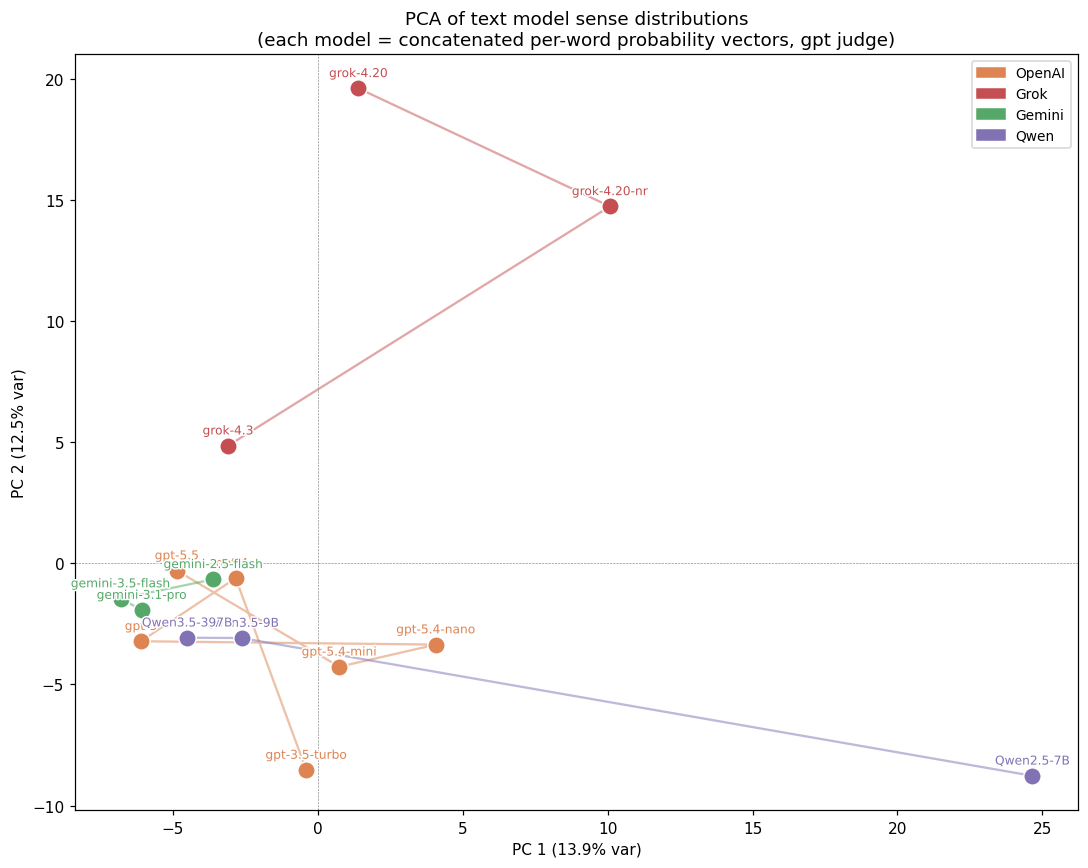

PCA variance explained: PC1=13.9%, PC2=12.5%


In [ ]:
print('=== TEXT PCA ===')
plot_pca('text')

### 8b. One Space, One Question: Is It Modality or Model Identity?

Sections 3–8 looked at image and text models *separately*. Here we put **every image and text model into a single sense-distribution space** — each model becomes one long vector of its concatenated per-word sense distributions over the words shared by both modalities — and PCA to 2D.

Text-only fingerprinting (McGovern et al. 2024) finds models cluster by **provider family**. The question here: once the *visual* sense signal is added, does family still dominate, or does **modality** become the primary axis? Two panels (colored by modality vs by family) plus **silhouette scores** quantify which label the geometry separates by.

**What to look for:**
- If the left panel (modality colour) separates cleanly and `silhouette(modality) > silhouette(family)`, then **the channel you query (image vs text) explains more of a model's polysemy behaviour than which model it is** — image and text generators behave like two different species, regardless of provider.

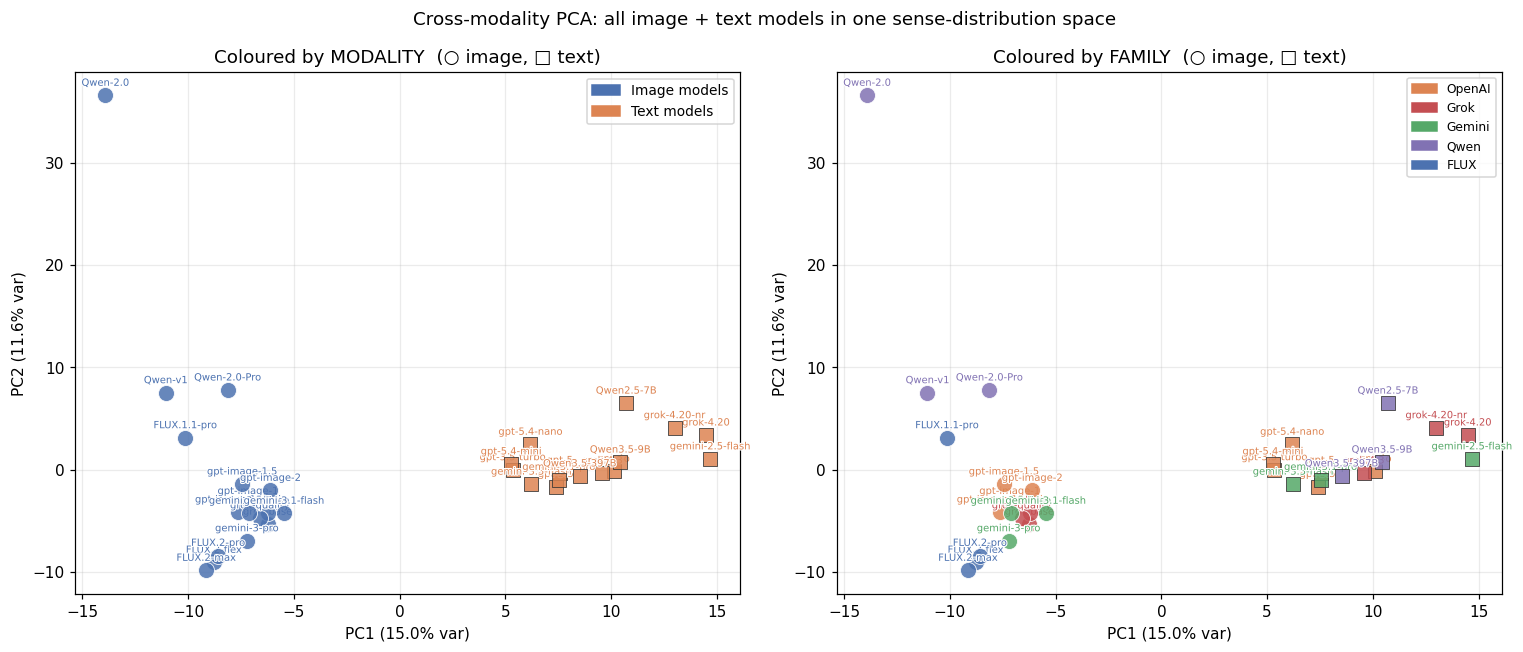

shared words: 100   models: 32 (17 image + 15 text)
  silhouette by MODALITY (image vs text): +0.274
  silhouette by FAMILY   (provider):      -0.044
  => MODALITY separates models more than identity does


In [ ]:
# ── 8b. All image + text models in ONE PCA space: modality vs model identity ──
# Each model -> a vector of its concatenated per-word sense distributions over the
# words shared by both modalities. PCA to 2D; silhouette scores say whether the
# geometry separates by modality (image/text) or by provider family. (= notebook
# cross-modality PCA using the inline helpers above.)
from sklearn.metrics import silhouette_score

def cross_modality_pca(judge='gpt'):
    shared = sorted(set(hist_image) & set(hist_text))
    labels_all = [(m, 'image') for m in IMAGE_MODELS] + [(m, 'text') for m in TEXT_MODELS]
    blocks = []
    for w in shared:
        vocab = get_vocab(w, hist_image[w], judge)
        for lbl in get_vocab(w, hist_text[w], judge):
            if lbl not in vocab:
                vocab.append(lbl)
        blocks.append((w, vocab))
    rows, labels = [], []
    for m, modality in labels_all:
        hist = hist_image if modality == 'image' else hist_text
        vec = []
        for w, vocab in blocks:
            md = hist.get(w, {}).get(m)
            d = dist_for(md, vocab, judge) if md is not None else None
            vec.extend(d if d is not None else np.zeros(len(vocab)))
        rows.append(vec); labels.append((m, modality))
    X = StandardScaler().fit_transform(np.array(rows))
    pca = PCA(n_components=2, random_state=42).fit(X)
    X2, var = pca.transform(X), pca.explained_variance_ratio_

    MK = {'image': 'o', 'text': 's'}
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, color_by in zip(axes, ['modality', 'family']):
        for i, (m, modality) in enumerate(labels):
            col = ('#4C72B0' if modality == 'image' else '#DD8452') if color_by == 'modality' else fcolor(family_of(m))
            ax.scatter(X2[i, 0], X2[i, 1], c=col, s=110 if modality == 'image' else 90,
                       marker=MK[modality], edgecolors='white' if modality == 'image' else '#333333',
                       linewidths=0.6, alpha=0.85, zorder=3)
            t = ax.annotate(dlabel(m), (X2[i, 0], X2[i, 1]), fontsize=6.5, ha='center',
                            va='bottom', xytext=(0, 5), textcoords='offset points', color=col)
            t.set_path_effects([pe.withStroke(linewidth=1.5, foreground='white')])
        ax.set_xlabel(f'PC1 ({var[0]:.1%} var)'); ax.set_ylabel(f'PC2 ({var[1]:.1%} var)')
        ax.grid(alpha=0.25)
        if color_by == 'modality':
            ax.set_title('Coloured by MODALITY  (○ image, □ text)')
            ax.legend(handles=[Patch(color='#4C72B0', label='Image models'),
                               Patch(color='#DD8452', label='Text models')], fontsize=9, loc='best')
        else:
            seen = {family_of(m) for m, _ in labels}
            ax.set_title('Coloured by FAMILY  (○ image, □ text)')
            ax.legend(handles=[Patch(color=fcolor(f), label=flabel(f)) for f in FAMILY_ORDER if f in seen],
                      fontsize=8, loc='best')
    fig.suptitle('Cross-modality PCA: all image + text models in one sense-distribution space', fontsize=12)
    plt.tight_layout(); plt.show()

    X10 = PCA(n_components=min(10, len(labels) - 1), random_state=42).fit_transform(X)
    mod_lab = np.array([0 if mm == 'image' else 1 for _, mm in labels])
    fam_lab = np.array([FAMILY_ORDER.index(family_of(m)) for m, _ in labels])
    sm, sf = silhouette_score(X10, mod_lab), silhouette_score(X10, fam_lab)
    print(f'shared words: {len(shared)}   models: {len(labels)} ({len(IMAGE_MODELS)} image + {len(TEXT_MODELS)} text)')
    print(f'  silhouette by MODALITY (image vs text): {sm:+.3f}')
    print(f'  silhouette by FAMILY   (provider):      {sf:+.3f}')
    print('  => ' + ('MODALITY separates models more than identity does'
                      if sm > sf else 'family separates models more than modality'))

cross_modality_pca('gpt')

## 9. Summary Statistics

Aggregated numbers across all words and models, useful for quick comparisons and for reporting headline results.

In [ ]:
def summary_stats(judge='gpt', prior_name='manual'):
    freq = freq_manual if prior_name == 'manual' else freq_wiki
    rows = []
    for modality, hist, models in [('image', hist_image, IMAGE_MODELS),
                                    ('text',  hist_text,  TEXT_MODELS)]:
        for m in models:
            js_prior_vals, pairwise_vals = [], []
            for word, word_data in hist.items():
                if m not in word_data: continue
                vocab = get_vocab(word, word_data, judge)
                d     = dist_for(word_data[m], vocab, judge)
                if d is None: continue
                # JS from prior
                tf = text_dist(word, vocab, freq)
                if tf is not None:
                    v = js(tf, d)
                    if not np.isnan(v): js_prior_vals.append(v)
                # max sense probability (dominance)
                pairwise_vals.append(float(d.max()))

            if not pairwise_vals: continue
            rows.append({
                'Modality':       modality,
                'Model':          dlabel(m),
                'Family':         flabel(family_of(m)),
                'Words covered':  len(pairwise_vals),
                'Mean JS (prior)':f'{np.mean(js_prior_vals):.4f}' if js_prior_vals else 'n/a',
                'Mean dominance': f'{np.mean(pairwise_vals):.3f}',
            })

    df = pd.DataFrame(rows)
    display(df.sort_values(['Modality', 'Family', 'Model']).reset_index(drop=True))
    return df

df_summary = summary_stats()
print("\n'Mean dominance' = average probability mass on the top sense (1.0 = always picks the same sense)")

,Modality,Model,Family,Words covered,Mean JS (prior),Mean dominance
0,image,FLUX.1.1-pro,FLUX,100,0.6162,0.884
1,image,FLUX.2-flex,FLUX,99,0.6100,0.880
2,image,FLUX.2-max,FLUX,99,0.6156,0.878
3,image,FLUX.2-pro,FLUX,100,0.6028,0.879
4,image,gemini-2.5-flash,Gemini,100,0.5858,0.908
5,image,gemini-3-pro,Gemini,100,0.5810,0.887
6,image,gemini-3.1-flash,Gemini,100,0.5578,0.897
7,image,grok-base,Grok,100,0.6241,0.946
8,image,grok-pro,Grok,100,0.5685,0.908
9,image,grok-quality,Grok,100,0.5973,0.942



'Mean dominance' = average probability mass on the top sense (1.0 = always picks the same sense)


## 10. Key Findings & Next Steps

### What this benchmark reveals

1. **Models are not neutral** — every model exhibits a measurable bias toward certain senses of polysemous words even when given no context. These biases are systematic and reproducible.

2. **Family clustering is real** — the similarity matrix and PCA consistently show that models from the same provider cluster more tightly than cross-family pairs. Training data and RLHF pipelines leave a 'house style' imprint on semantic representations.

3. **Image and text modalities diverge** — across all 100 words, image models and text models from the same family often resolve polysemy differently, suggesting that visual and verbal 'meaning' are not fully unified even within a single lab.

4. **Newer is not always 'more natural'** — the generation trend plots show mixed evidence. Some families' newer models converge toward text-frequency priors; others diverge further.

5. **Some words are universal battlegrounds** — the inter-model disagreement chart identifies words where no model agrees with any other. These are the hardest polysemy cases and may serve as diagnostic probes for model behaviour.

### Limitations

- 13 text words are each missing 1–33 samples (out of 450 total per word) due to API errors during generation. Results for those words are based on slightly fewer samples but are still reliable.
- Judges (GPT and Gemini) may carry their own biases when classifying sense — inter-judge agreement should be reported alongside results.
- Words were chosen partly for clear senses and partly for being culturally salient brand names (e.g. Amazon, Jordan, Jaguar), which may skew results toward those associations.

### To extend this analysis

```bash
# Add a new model (one line in registry.py, then re-run eval + classify)
python -m llm_polysemy.eval --modality text --model <new_key>
python -m llm_polysemy.classify --modality text
python -m llm_polysemy.classify --modality text --histograms

# Regenerate all static figures
python -m llm_polysemy.plots.similarity --modality text
python -m llm_polysemy.plots.vs_textfreq --modality text
python -m llm_polysemy.plots.generation_trend --modality text
python -m llm_polysemy.plots.pca_tsne --modality text
python -m llm_polysemy.plots.word_disagreement --modality text
```


## 11. Human Alignment: Which Models Look Most Like People, and Where Do They Agree?

Two analyses, both respecting that **each side answered under different prompts**
("multiple prompts"), so every comparison stays *within* its matching condition:

- **MEANING** (use the word in a sentence): human `meaning` survey ↔ **text** models.
- **IMAGE** (the image the word evokes): human `image` survey ↔ **image** models, and —
  once it is classified — the **`text-imagine`** condition, whose prompt is *verbatim* the
  human `image` survey, making it the cleanest like-for-like comparison.

**Metric.** For every (model, word) we build a sense distribution over the shared vocab
(every label the human *or* that model used for the word, including `multiple/unclear/other`)
and score **similarity = 1 - Jensen-Shannon divergence** (base-2, in [0, 1]; 1 = identical).
Judge = `gpt`. *Analysis 1* averages this per model (who is most human-like?); *Analysis 2*
averages it per word across models (where do people and models converge?).

ANALYSIS 1 -- most human-like models  (similarity = 1 - JS divergence, judge=gpt)

[MEANING (sentence)]
   1. gemini_25flash   0.853  (n=100)
   2. openai_35        0.840  (n=100)
   3. openai_5         0.839  (n=100)
   4. gemini_31pro     0.830  (n=100)
   5. grok_43          0.828  (n=100)
   6. openai_4o        0.824  (n=100)
   7. openai_54mini    0.821  (n=100)
   8. grok_420         0.808  (n=100)
   9. qwen_35_397b     0.797  (n=100)
  10. qwen_35_9b       0.796  (n=100)
  11. gemini_35flash   0.790  (n=100)
  12. grok_420_nr      0.788  (n=100)
  13. qwen_25_7b       0.775  (n=100)
  14. openai_54nano    0.772  (n=100)
  15. openai_55        0.767  (n=100)

[IMAGE (depict)]
   1. gemini_pro       0.794  (n=100)
   2. grok_pro         0.777  (n=100)
   3. gemini           0.776  (n=100)
   4. gemini_25        0.771  (n=100)
   5. flux             0.767  (n=100)
   6. flux_flex        0.765  (n=99)
   7. flux_max         0.760  (n=99)
   8. grok             0.755  (n=100)
   9. 

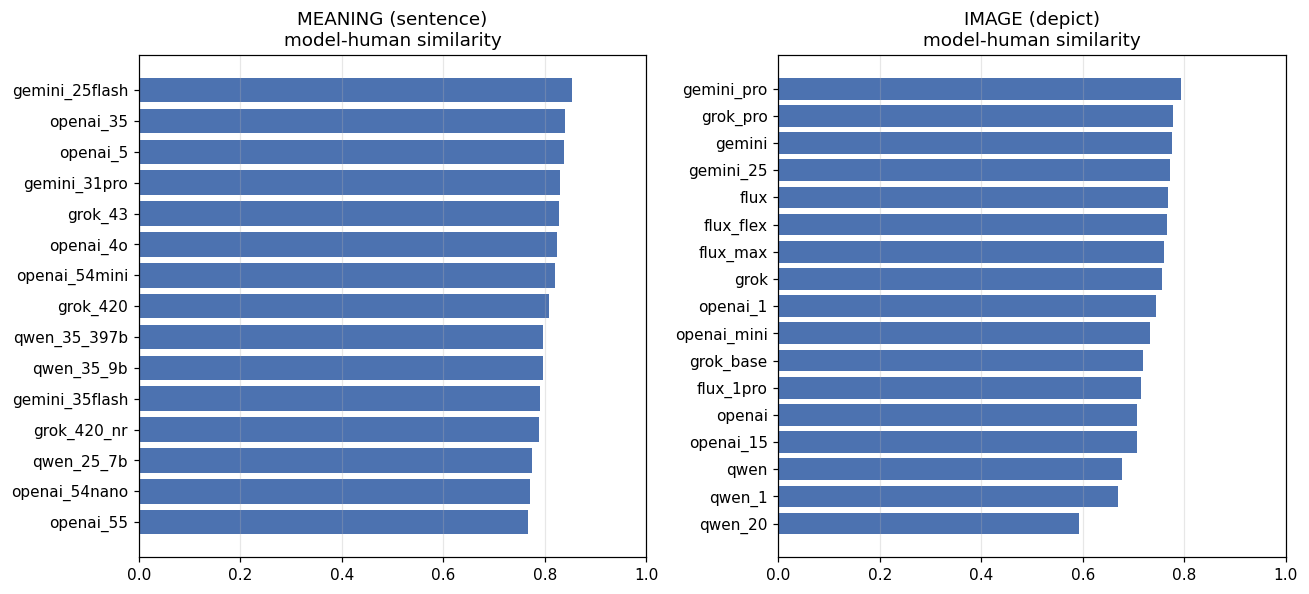

In [ ]:
# -- 11. Human alignment by prompt condition -- model-human similarity ----------
# "Multiple prompts" => two conditions, compared like-with-like:
#   MEANING (sentence): human_meaning <-> text models
#   IMAGE   (depict):   human_image   <-> image models, + text-imagine once classified
#                       (text-imagine wording == human image survey => cleanest match).
# similarity = 1 - JS_divergence(human, model) over the per-word shared vocab, judge=gpt.
import json, numpy as np
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

JUDGE = 'gpt'
_D = Path('data')
_ld = lambda n: json.load(open(_D / f'{n}.json')) if (_D / f'{n}.json').exists() else None
H_MEAN, H_IMG = _ld('histograms_human_meaning'), _ld('histograms_human_image')
M_TEXT, M_IMG, M_IMAG = _ld('histograms_text'), _ld('histograms_image'), _ld('histograms_text_imagine')

def _counts(node):
    if not node or JUDGE not in node: return None
    return node[JUDGE].get('_counts') or None

def _jsd(p, q):
    p, q = np.asarray(p, float), np.asarray(q, float); m = .5 * (p + q)
    kl = lambda a, b: float(np.sum(a[a > 0] * np.log2(a[a > 0] / b[a > 0])))
    return .5 * kl(p, m) + .5 * kl(q, m)

def _sim(hc, mc):
    v = sorted(set(hc) | set(mc))
    hp = np.array([hc.get(k, 0) for k in v], float); hp /= hp.sum()
    mp = np.array([mc.get(k, 0) for k in v], float); mp /= mp.sum()
    return 1 - _jsd(hp, mp)

def _model_keys(h):
    s = set()
    for w in h: s |= set(h[w])
    return sorted(s)

def human_align(human_hist, model_hist):
    per_model, per_word = {}, {}
    if not human_hist or not model_hist: return per_model, per_word
    for m in _model_keys(model_hist):
        sims = []
        for w in human_hist:
            hc = _counts(human_hist[w].get('human')); mc = _counts(model_hist.get(w, {}).get(m))
            if hc and mc:
                s = _sim(hc, mc); sims.append(s); per_word.setdefault(w, []).append((m, s))
        if sims: per_model[m] = (float(np.mean(sims)), len(sims))
    return per_model, per_word

CONDS = [('MEANING (sentence)', H_MEAN, M_TEXT), ('IMAGE (depict)', H_IMG, M_IMG)]
if M_IMAG:                                   # appears once text-imagine is classified
    CONDS.append(('IMAGE (text-imagine)', H_IMG, M_IMAG))
RES = {n: human_align(hh, mh) for n, hh, mh in CONDS}

# ----- Analysis 1: models most similar to humans (per condition) -----
print('ANALYSIS 1 -- most human-like models  (similarity = 1 - JS divergence, judge=gpt)')
for name, _, _ in CONDS:
    pm, _ = RES[name]
    print(f'\n[{name}]')
    for r, (m, (mean, n)) in enumerate(sorted(pm.items(), key=lambda x: -x[1][0]), 1):
        print(f'  {r:2d}. {m:16s} {mean:.3f}  (n={n})')

fig, axes = plt.subplots(1, len(CONDS), figsize=(6 * len(CONDS), 5.5), squeeze=False)
for ax, (name, _, _) in zip(axes[0], CONDS):
    pm, _ = RES[name]
    items = sorted(pm.items(), key=lambda x: x[1][0])
    ax.barh([m for m, _ in items], [v[0] for _, v in items], color='#4C72B0')
    ax.set_xlim(0, 1); ax.set_title(f'{name}\nmodel-human similarity'); ax.grid(axis='x', alpha=.3)
plt.tight_layout(); plt.show()


=== MEANING (sentence) -- most-convergent words ===
  word             sim  human-sense(share)  model-consensus
  ball           1.000      sphere(100%)   sphere
  cobra          0.999       snake(100%)   snake
  fox            0.999      animal(100%)   animal
  basket         0.998   container(100%)   container
  hide           0.995     conceal(100%)   conceal
  fire           0.994      flames(100%)   flames
  pen            0.991     writing(100%)   writing
  ash            0.987     residue(100%)   residue
  cape           0.982       cloak(100%)   cloak
  bench          0.980        seat(100%)   seat
  plane          0.972    aircraft(100%)   aircraft
  jaguar         0.968      animal(93%)   animal
  --- least-convergent ---
  pitch          0.436  human=throw(29%)
  shot           0.452  human=attempt(54%)
  bug            0.553  human=insect(94%)
  case           0.598  human=container(43%)
  post           0.608  human=pole(43%)
  seal           0.619  human=close(54%)

=== 

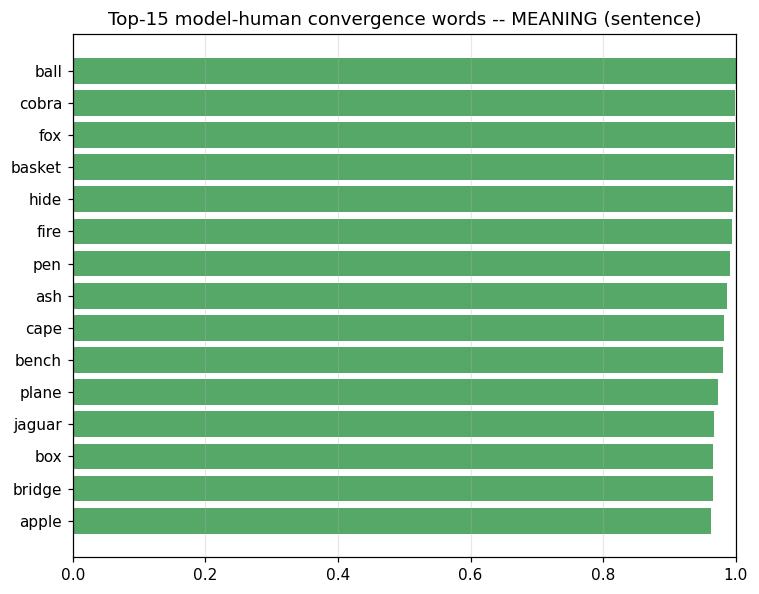

In [ ]:
# -- 11b. Words where models & humans converge most (per condition) ------------
def _human_dom(hist, w):
    c = _counts(hist[w].get('human')) if w in hist else None
    if not c: return ('-', 0.0)
    t = sum(c.values()); k = max(c, key=c.get); return (k, c[k] / t)

for name, hh, mh in CONDS:
    _, per_word = RES[name]
    wmean = {w: float(np.mean([s for _, s in lst])) for w, lst in per_word.items()}
    print(f'\n=== {name} -- most-convergent words ===')
    print(f"  {'word':14s} {'sim':>5s}  human-sense(share)  model-consensus")
    for w, s in sorted(wmean.items(), key=lambda x: -x[1])[:12]:
        hl, hsh = _human_dom(hh, w)
        dl = Counter()
        for m in _model_keys(mh):
            c = _counts(mh.get(w, {}).get(m))
            if c: dl[max(c, key=c.get)] += 1
        ml = dl.most_common(1)[0][0] if dl else '-'
        print(f'  {w:14s} {s:.3f}  {hl:>10s}({hsh:.0%})   {ml}')
    print('  --- least-convergent ---')
    for w, s in sorted(wmean.items(), key=lambda x: x[1])[:6]:
        hl, hsh = _human_dom(hh, w)
        print(f'  {w:14s} {s:.3f}  human={hl}({hsh:.0%})')

# quick visual: top-15 convergent words for the first condition
name0 = CONDS[0][0]; _, pw0 = RES[name0]
wm0 = {w: float(np.mean([s for _, s in lst])) for w, lst in pw0.items()}
top = sorted(wm0.items(), key=lambda x: -x[1])[:15][::-1]
plt.figure(figsize=(7, 5.5))
plt.barh([w for w, _ in top], [s for _, s in top], color='#55A868')
plt.xlim(0, 1); plt.title(f'Top-15 model-human convergence words -- {name0}')
plt.grid(axis='x', alpha=.3); plt.tight_layout(); plt.show()

## 12. Stated vs Revealed: Do Models Know What They (and People) Will Do?

A metacognition probe. Alongside *generating*, each text model was asked to **estimate** the
human sense distribution under each framing -- "of 100 people shown only this word, what % land
on each meaning?" -- forced to `sense: percentage` rows (the **stated** distribution). We then
compare three quantities over each word's **canonical senses** (judge=gpt):

- **self-knowledge** -- stated vs the model's *own* generations (`text` / `text-imagine`): does a
  model know how *it* behaves?
- **predict-human** -- stated vs the human survey: does it know how *people* behave?
- **behavior-human** -- generations vs human (the §11 view, restricted to canonical senses).

Image models can't state probabilities, so this is the **14 text models** (the two Qwen-35b
variants drop out -- they wouldn't follow the row format).

**Headline.** `predict-human > behavior-human > self-knowledge`: models' *stated* beliefs are
**more human-aligned than their own sampling**, and they are **least accurate about themselves** --
they predict the population better than they predict their own outputs.


[MEANING]   self-know  pred-hum  behav-hum   (n words)
  grok_420            0.830     0.900     0.841   (100)
  openai_5            0.829     0.903     0.876   (100)
  gemini_25flash      0.822     0.885     0.887   (100)
  grok_43             0.822     0.904     0.858   (100)
  openai_54mini       0.822     0.886     0.859   (100)
  openai_4o           0.821     0.893     0.860   (100)
  gemini_31pro        0.813     0.927     0.868   (100)
  openai_35           0.810     0.882     0.870   (100)
  grok_420_nr         0.792     0.898     0.819   (100)
  gemini_35flash      0.787     0.923     0.823   (100)
  openai_55           0.757     0.918     0.801   (100)
  openai_54nano       0.747     0.848     0.808   (100)
  qwen_25_7b          0.715     0.834     0.808   (99)
  -- MEAN --          0.797     0.892     0.845

[IMAGE]   self-know  pred-hum  behav-hum   (n words)
  gemini_35flash      0.788     0.932     0.805   (100)
  gemini_31pro        0.786     0.936     0.800   (100)
  g

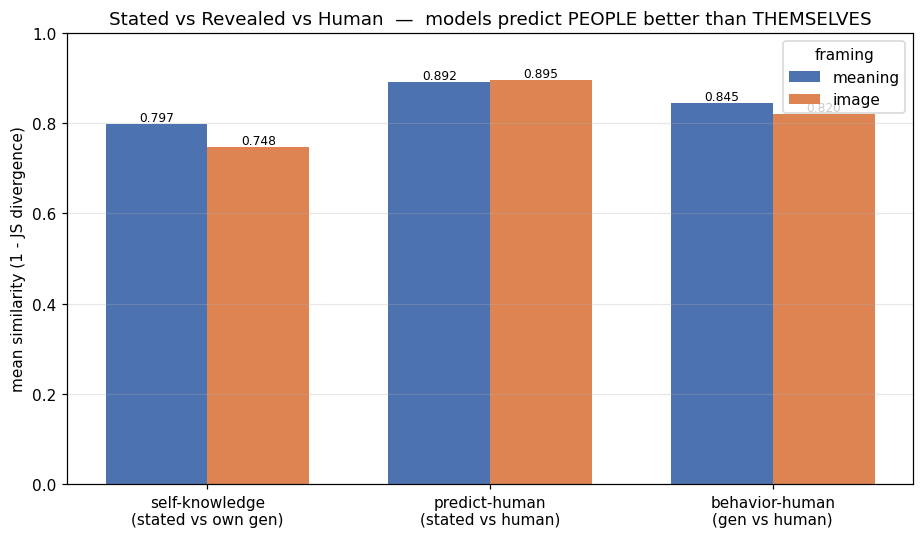

In [ ]:
# -- 12. Stated vs revealed vs human, over each word's canonical senses (gpt) ---
import json, numpy as np
import matplotlib.pyplot as plt
from llm_polysemy.meanings import load_meanings
from llm_polysemy.registry import models_for

MEAN = load_meanings('data/meanings.json'); MODELS = models_for('text'); JUDGE = 'gpt'
_ld = lambda n: json.load(open(f'data/{n}.json'))
STA = {'meaning': _ld('stated_meaning'),         'image': _ld('stated_image')}
REV = {'meaning': _ld('histograms_text'),        'image': _ld('histograms_text_imagine')}
HUM = {'meaning': _ld('histograms_human_meaning'),'image': _ld('histograms_human_image')}

def _jsd(p, q):
    p, q = np.asarray(p, float), np.asarray(q, float); m = .5*(p+q)
    kl = lambda a, b: float(np.sum(a[a>0]*np.log2(a[a>0]/b[a>0])))
    return .5*kl(p, m)+.5*kl(q, m)
_sim = lambda p, q: 1 - _jsd(p, q)
_canon = lambda w: [s['sense'] for s in MEAN[w]]
def _vc(node, w):
    if not node or JUDGE not in node: return None
    c = node[JUDGE].get('_counts', {}); v = np.array([c.get(s, 0) for s in _canon(w)], float)
    return v/v.sum() if v.sum() else None
def _vs(d, w):
    if not d: return None
    v = np.array([d.get(s, 0) for s in _canon(w)], float)
    return v/v.sum() if v.sum() else None

STAT = {}
for fr in ['meaning', 'image']:
    rows, agg = [], {'self': [], 'pred': [], 'behav': []}
    for m in MODELS:
        ss, sp, sb = [], [], []
        for w in MEAN:
            st = _vs(STA[fr].get(w, {}).get(m, {}).get('dist'), w)
            rv = _vc(REV[fr].get(w, {}).get(m), w)
            hu = _vc(HUM[fr].get(w, {}).get('human'), w)
            if st is not None and rv is not None: ss.append(_sim(st, rv))
            if st is not None and hu is not None: sp.append(_sim(st, hu))
            if rv is not None and hu is not None: sb.append(_sim(rv, hu))
        if len(ss) >= 50:                  # enough stated cells (drops Qwen-35b format fails)
            rows.append((m, np.mean(ss), np.mean(sp), np.mean(sb), len(ss)))
            agg['self'] += ss; agg['pred'] += sp; agg['behav'] += sb
    STAT[fr] = (rows, agg)
    print(f"\n[{fr.upper()}]   self-know  pred-hum  behav-hum   (n words)")
    for m, se, pr, be, n in sorted(rows, key=lambda x: -x[1]):
        print(f"  {m:16s} {se:8.3f} {pr:9.3f} {be:9.3f}   ({n})")
    print(f"  {'-- MEAN --':16s} {np.mean(agg['self']):8.3f} {np.mean(agg['pred']):9.3f} {np.mean(agg['behav']):9.3f}")

# grouped bars: the three mean similarities per framing
fig, ax = plt.subplots(figsize=(8.5, 5))
labels = ['self-knowledge\n(stated vs own gen)', 'predict-human\n(stated vs human)', 'behavior-human\n(gen vs human)']
x = np.arange(len(labels)); bw = 0.36
for i, fr in enumerate(['meaning', 'image']):
    _, agg = STAT[fr]
    vals = [np.mean(agg['self']), np.mean(agg['pred']), np.mean(agg['behav'])]
    bars = ax.bar(x + (i-0.5)*bw, vals, bw, label=fr, color=['#4C72B0', '#DD8452'][i])
    ax.bar_label(bars, fmt='%.3f', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylim(0, 1)
ax.set_ylabel('mean similarity (1 - JS divergence)')
ax.set_title('Stated vs Revealed vs Human  —  models predict PEOPLE better than THEMSELVES')
ax.legend(title='framing'); ax.grid(axis='y', alpha=.3); plt.tight_layout(); plt.show()

### 12b. Stated vs Generated Entropy — the calibration gap (predict-people AND predict-self)

For each (model, word) we take the normalised entropy (canonical senses) of the model's
**stated** distribution and its **actual generation**, and test the paired difference. We do
this for *both* prior types so they can be compared head-to-head:

- **population** prior — *"A survey of 100 English speakers… estimate the % whose sentence/
  mental image…"* (predicts **people**);
- **self** prior — *"…suppose you did this 100 independent times… estimate the % of your
  sentences/descriptions/images…"* (predicts **itself**; includes an image-**generation**
  framing: *"generate an image given the word prompt: X"*).

Result: models **state far more sense diversity than they generate** (95-99% of cells,
Cohen's d ≈ 1.2-2.8) — and the **self gap ≈ the population gap**. So the over-statement is a
*general introspection failure*, not a quirk of modelling other people: asked to predict its
**own** output a model still vastly over-states its spread. (Consistent with §12's low
`self-knowledge` similarity.)

[MEANING] gen=text  n=1312  stated=0.721 gen=0.249  diff=+0.472  stated>gen 95%  Wilcoxon p=2.6e-204  t=60.4  Cohen_d=1.67
   word-wise avg diff = +0.473 (median +0.483, range +0.11..+0.79); max-gap words: paddle, jaguar, port, mortar; min-gap: chest, bridge, bolt, match
[IMAGE] gen=text-imagine  n=1308  stated=0.730 gen=0.088  diff=+0.642  stated>gen 99%  Wilcoxon p=1.7e-214  t=102.6  Cohen_d=2.84
   word-wise avg diff = +0.642 (median +0.663, range +0.24..+0.86); max-gap words: block, match, ram, case; min-gap: bridge, cobra, pen, jordan


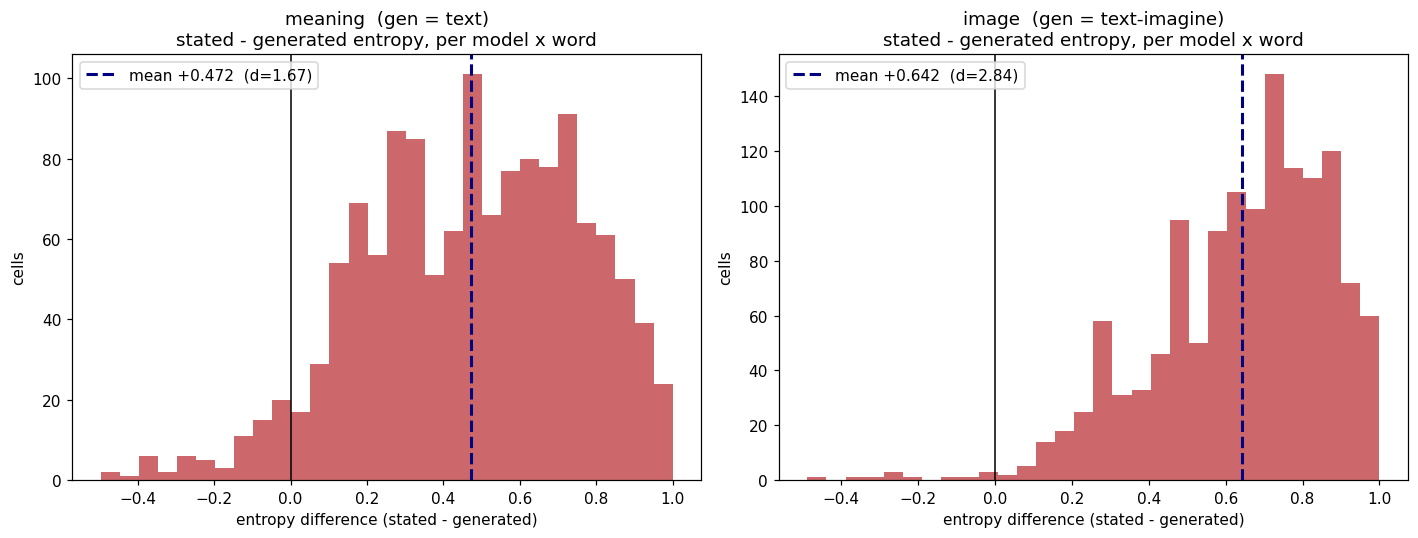

In [ ]:
# -- 12b. Stated vs generated entropy gap: population AND self priors -----------
import json, numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from llm_polysemy.meanings import load_meanings
from llm_polysemy.registry import models_for

MEAN = load_meanings('data/meanings.json'); MODELS = models_for('text'); J = 'gpt'
_ld = lambda n: json.load(open(f'data/{n}.json'))
_canon = lambda w: [s['sense'] for s in MEAN[w]]
def _ne(p):
    p = np.asarray(p, float)
    if p.sum() == 0: return None
    p /= p.sum(); k = len(p)
    return 0.0 if k < 2 else float(-np.sum(p[p > 0] * np.log2(p[p > 0])) / np.log2(k))
def _sta(d, w):
    if not d: return None
    v = np.array([d.get(s, 0) for s in _canon(w)], float); return _ne(v) if v.sum() else None
def _gen_model(node, w):
    if not node or J not in node: return None
    c = node[J].get('_counts', {}); v = np.array([c.get(s, 0) for s in _canon(w)], float)
    return _ne(v) if v.sum() else None
def _gen_pooled(word_node, w):          # aggregate counts across all models for the word
    agg = {}
    for m, node in word_node.items():
        if J in node:
            for s, c in node[J].get('_counts', {}).items(): agg[s] = agg.get(s, 0) + c
    v = np.array([agg.get(s, 0) for s in _canon(w)], float); return _ne(v) if v.sum() else None

# (label, stated-file, gen-histogram, gen-mode)
RUNS = [
    ('population: meaning', 'stated_meaning',      'histograms_text',          'model'),
    ('population: image',   'stated_image',        'histograms_text_imagine',  'model'),
    ('self: meaning',       'stated_self_meaning', 'histograms_text',          'model'),
    ('self: image',         'stated_self_image',   'histograms_text_imagine',  'model'),
    ('self: imagegen',      'stated_self_imagegen','histograms_image',         'pooled'),
]
rows = []
for label, sf, gf, mode in RUNS:
    STA, REV = _ld(sf), _ld(gf)
    S, G = [], []
    for w in MEAN:
        gp = _gen_pooled(REV.get(w, {}), w) if mode == 'pooled' else None
        for m in MODELS:
            s = _sta(STA.get(w, {}).get(m, {}).get('dist'), w)
            g = gp if mode == 'pooled' else _gen_model(REV.get(w, {}).get(m), w)
            if s is not None and g is not None: S.append(s); G.append(g)
    S, G = np.array(S), np.array(G); diff = S - G
    W, p = wilcoxon(S, G); d = diff.mean() / diff.std()
    rows.append((label, S.mean(), G.mean(), diff.mean(), 100*(diff > 0).mean(), p, d, len(diff)))
    print(f"  {label:20s} stated={S.mean():.3f} gen={G.mean():.3f} gap={diff.mean():+.3f} "
          f"stated>gen {100*(diff>0).mean():3.0f}%  d={d:.2f}  p={p:.1e}  (n={len(diff)})")

print("\n  KEY: self gap ~= population gap -> over-statement is general (introspection), not people-specific.")

# bar: population vs self entropy gap, meaning & image (+ self imagegen)
import numpy as np
labels = ['meaning', 'image', 'imagegen']
pop = {r[0].split(': ')[1]: r[3] for r in rows if r[0].startswith('population')}
slf = {r[0].split(': ')[1]: r[3] for r in rows if r[0].startswith('self')}
x = np.arange(len(labels)); bw = 0.38
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - bw/2, [pop.get(l, np.nan) for l in labels], bw, label='population prior', color='#4C72B0')
ax.bar(x + bw/2, [slf.get(l, np.nan) for l in labels], bw, label='self prior', color='#DD8452')
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel('entropy gap (stated - generated)')
ax.set_title('Stated over-states spread vs actual generation\n(self gap ~= population gap: general introspection failure)')
ax.legend(); ax.grid(axis='y', alpha=.3)
for i, l in enumerate(labels):
    if l in pop: ax.text(i - bw/2, pop[l]+.01, f"{pop[l]:+.2f}", ha='center', fontsize=8)
    if l in slf: ax.text(i + bw/2, slf[l]+.01, f"{slf[l]:+.2f}", ha='center', fontsize=8)
plt.tight_layout(); plt.show()

## 13. Preference-Tuning Ablations — Legibility vs Sense-Choice (AR vs Diffusion)

Two base→tuned image-model ablations, judged identically, each decomposed into a **legibility**
channel (the `unclear`/`other` rate) vs a **sense-choice** channel (entropy over *real senses only*):
- **Autoregressive:** SimpleAR-1.5B **SFT → RL** (`simplear_sft` / `simplear_rl`)
- **Diffusion:** SDXL **base → DPO** (`sdxl_base` / `sdxl_dpo`)

**Finding — architecture-dependent (the honest claim):** Both cut *total* entropy mainly via
**legibility** (lower `unclear`). But on the **real-sense** distribution they diverge: SimpleAR
**RL leaves sense-choice unchanged** (n.s.), while SDXL **DPO significantly narrows** which sense
wins (p≈0.01). So preference-tuning sharpens *rendering* in both, but only the **diffusion** model
also shifts *meaning*. *Caveat:* SDXL's base is more diffuse (canonical 0.247 vs 0.108), so part of
the gap is base-model headroom, not purely architecture — and even for SDXL the legibility channel
(raw p≈5e-6) dominates the sense-choice one (canonical p≈0.01).


=== Autoregressive: SimpleAR SFT→RL ===
  raw (with unclear)       base=0.365 tuned=0.301 diff=+0.064 p=8.7e-04 *** (n=100)
  canonical (real senses)  base=0.108 tuned=0.096 diff=+0.012 p=1.2e-01 n.s. (n=97)
  unclear/other rate       base=22.8% tuned=19.1%

=== Diffusion: SDXL base→DPO ===
  raw (with unclear)       base=0.510 tuned=0.370 diff=+0.140 p=5.0e-06 *** (n=100)
  canonical (real senses)  base=0.247 tuned=0.175 diff=+0.072 p=1.1e-02 * (n=99)
  unclear/other rate       base=28.3% tuned=20.7%


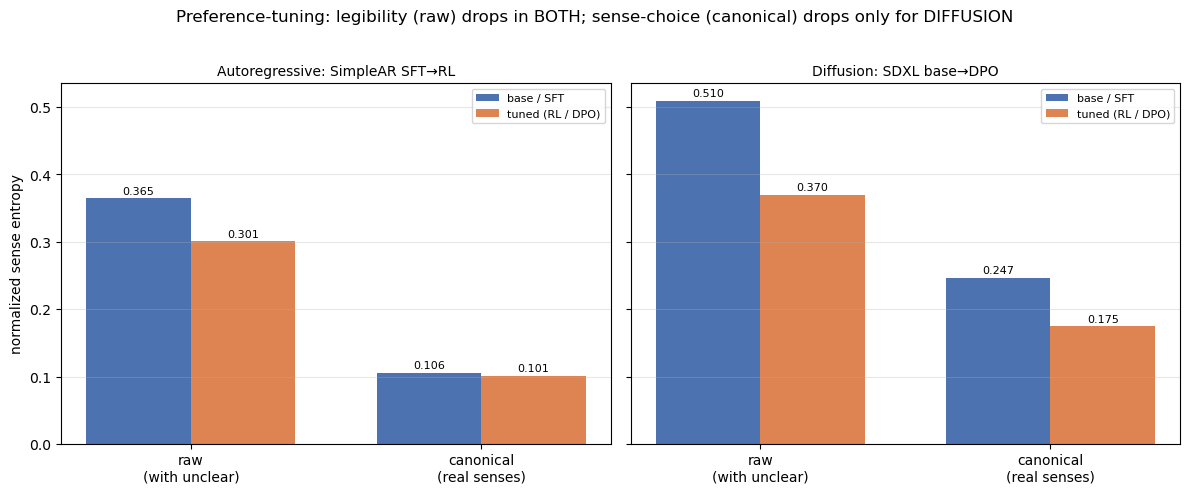

In [ ]:
# -- 13. Preference-tuning ablations: legibility vs sense-choice (AR vs diffusion) -
import json, numpy as np
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
from llm_polysemy.meanings import load_meanings

MEAN = load_meanings('data/meanings.json'); J = 'gpt'
HI = json.load(open('data/histograms_image.json'))
canon = lambda w: [s['sense'] for s in MEAN[w]]
NON = {'unclear', 'other', 'multiple'}
def _ne(p):
    p = np.asarray(p, float)
    if p.sum() == 0: return None
    p /= p.sum(); k = len(p)
    return 0.0 if k < 2 else -np.sum(p[p > 0] * np.log2(p[p > 0])) / np.log2(k)
def _c(w, m):
    n = HI.get(w, {}).get(m, {}); return n[J].get('_counts', {}) if J in n else None
def _raw(w, m):
    c = _c(w, m); return _ne(np.array(list(c.values()), float)) if c else None
def _canon(w, m):
    c = _c(w, m)
    if not c: return None
    v = np.array([c.get(s, 0) for s in canon(w)], float); return _ne(v) if v.sum() else None
def _unc(m):
    nn = tt = 0
    for w in HI:
        c = _c(w, m) or {}; tt += sum(c.values()); nn += sum(v for k, v in c.items() if k in NON)
    return nn / tt if tt else 0
def _mean(fn, m): return np.mean([e for w in MEAN if (e := fn(w, m)) is not None])
def _paired(fn, base, tuned):
    pr = [(a, b) for w in MEAN if (a := fn(w, base)) is not None and (b := fn(w, tuned)) is not None]
    a = np.array([x for x, _ in pr]); b = np.array([y for _, y in pr]); _, p = wilcoxon(a, b)
    return a.mean(), b.mean(), p, len(pr)

ABL = [("Autoregressive: SimpleAR SFT→RL", "simplear_sft", "simplear_rl"),
       ("Diffusion: SDXL base→DPO",        "sdxl_base",    "sdxl_dpo")]
for name, base, tuned in ABL:
    print(f"\n=== {name} ===")
    for lab, fn in [("raw (with unclear)", _raw), ("canonical (real senses)", _canon)]:
        bm, tm, p, n = _paired(fn, base, tuned)
        sig = '***' if p < 1e-3 else ('*' if p < .05 else 'n.s.')
        print(f"  {lab:24s} base={bm:.3f} tuned={tm:.3f} diff={bm-tm:+.3f} p={p:.1e} {sig} (n={n})")
    print(f"  {'unclear/other rate':24s} base={_unc(base)*100:.1f}% tuned={_unc(tuned)*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
for ax, (name, base, tuned) in zip(axes, ABL):
    groups = ['raw\n(with unclear)', 'canonical\n(real senses)']
    bv = [_mean(_raw, base), _mean(_canon, base)]
    tv = [_mean(_raw, tuned), _mean(_canon, tuned)]
    x = np.arange(2); bw = 0.36
    ax.bar(x - bw/2, bv, bw, label='base / SFT', color='#4C72B0')
    ax.bar(x + bw/2, tv, bw, label='tuned (RL / DPO)', color='#DD8452')
    for i in range(2):
        ax.text(i - bw/2, bv[i] + .006, f'{bv[i]:.3f}', ha='center', fontsize=8)
        ax.text(i + bw/2, tv[i] + .006, f'{tv[i]:.3f}', ha='center', fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(groups); ax.set_title(name, fontsize=10)
    ax.grid(axis='y', alpha=.3); ax.legend(fontsize=8)
axes[0].set_ylabel('normalized sense entropy')
fig.suptitle('Preference-tuning: legibility (raw) drops in BOTH; sense-choice (canonical) drops only for DIFFUSION', y=1.02)
plt.tight_layout(); plt.show()